In [2]:
import torch
import numpy as np
import nibabel as nib
import SimpleITK as sitk
import matplotlib.pyplot as plt

print("Environment ready!")
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

Environment ready!
PyTorch: 2.13.0+cpu
CUDA: False


In [3]:
import os

print("Jupyter is currently working in:")
print(os.getcwd())

print("\nFolders here:")
print(os.listdir())

Jupyter is currently working in:
C:\Users\asus

Folders here:
['.android', '.antigravity', '.antigravity-ide', '.cache', '.codeium', '.codex', '.copilot', '.dotnet', '.gemini', '.gitconfig', '.gradle', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jdks', '.jupyter', '.lesshst', '.skiko', '.streamlit', '.templateengine', '.vscode', '.vscode-shared', '.windsurf', 'AppData', 'Application Data', 'CascadeProjects', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'flutter', 'IdeaProjects', 'index.html', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{a5bec1d5-7b7c-11f0-ad16-95efb55f3194}.TM.blf', 'NTUSER.DAT{a5bec1d5-7b7c-11f0-ad16-95efb55f3194}.TM.blf.cnpf', 'NTUSER.DAT{a5bec1d5-7b7c-11f0-ad16-95efb55f3194}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{a5bec1d5-7b7c-11f0-ad16-95efb55f3194}.TMContainer00000000000000000001.regtrans-ms.cnpf', 'NTUSER.DAT

In [4]:
import os

home = r"C:\Users\asus"

print("Searching for OAI_Module1...")

for root, dirs, files in os.walk(home):
    if "OAI_Module1" in dirs:
        full_path = os.path.join(root, "OAI_Module1")
        print("\nFOUND:")
        print(full_path)

Searching for OAI_Module1...

FOUND:
C:\Users\asus\Downloads\OAI_Module1


In [5]:
import os

dataset_path = r"C:\Users\asus\Downloads\OAI_Module1"

print("Dataset path:")
print(dataset_path)

print("\nFolders:")
print(os.listdir(dataset_path))

Dataset path:
C:\Users\asus\Downloads\OAI_Module1

Folders:
['V00', 'V01', 'V03', 'V05', 'V06', 'V08', 'V10']


In [6]:
import os

v00_path = os.path.join(dataset_path, "V00")

print("V00 path:")
print(v00_path)

files = os.listdir(v00_path)

print("\nNumber of files:", len(files))
print("\nFirst 20 files:")

for f in files[:20]:
    print(f)

V00 path:
C:\Users\asus\Downloads\OAI_Module1\V00

Number of files: 9395

First 20 files:
9000099_LEFT_0.npz
9000296_RIGHT_0.npz
9000622_LEFT_0.npz
9000622_RIGHT_0.npz
9000798_LEFT_0.npz
9000798_RIGHT_0.npz
9001104_LEFT_0.npz
9001104_RIGHT_0.npz
9001400_LEFT_0.npz
9001400_RIGHT_0.npz
9001695_LEFT_0.npz
9001695_RIGHT_0.npz
9001897_LEFT_0.npz
9001897_RIGHT_0.npz
9002116_LEFT_0.npz
9002116_RIGHT_0.npz
9002316_LEFT_0.npz
9002316_RIGHT_0.npz
9002411_LEFT_0.npz
9002411_RIGHT_0.npz


In [7]:
import numpy as np
import os

sample_file = os.path.join(
    dataset_path,
    "V00",
    "9000099_LEFT_0.npz"
)

print("Loading:")
print(sample_file)

data = np.load(sample_file)

print("\nKeys inside NPZ:")
print(data.files)

for key in data.files:
    x = data[key]

    print("\n==============================")
    print("Key:", key)
    print("Shape:", x.shape)
    print("Dtype:", x.dtype)
    print("Min:", x.min())
    print("Max:", x.max())
    print("Number of unique values:", len(np.unique(x)))
    print("First unique values:", np.unique(x)[:50])

Loading:
C:\Users\asus\Downloads\OAI_Module1\V00\9000099_LEFT_0.npz

Keys inside NPZ:
['x']

Key: x
Shape: (364, 364, 150)
Dtype: uint8
Min: 0
Max: 7
Number of unique values: 8
First unique values: [0 1 2 3 4 5 6 7]


In [8]:
from collections import Counter
import numpy as np

x = data["x"]

print("Label statistics")
print("================")

total = x.size

for label in range(8):
    count = np.sum(x == label)
    percentage = 100 * count / total

    print(
        f"Label {label}: "
        f"{count:,} voxels "
        f"({percentage:.4f}%)"
    )

Label statistics
Label 0: 15,957,767 voxels (80.2931%)
Label 1: 2,266,572 voxels (11.4045%)
Label 2: 1,138,588 voxels (5.7289%)
Label 3: 256,185 voxels (1.2890%)
Label 4: 141,798 voxels (0.7135%)
Label 5: 34,500 voxels (0.1736%)
Label 6: 31,689 voxels (0.1594%)
Label 7: 47,301 voxels (0.2380%)


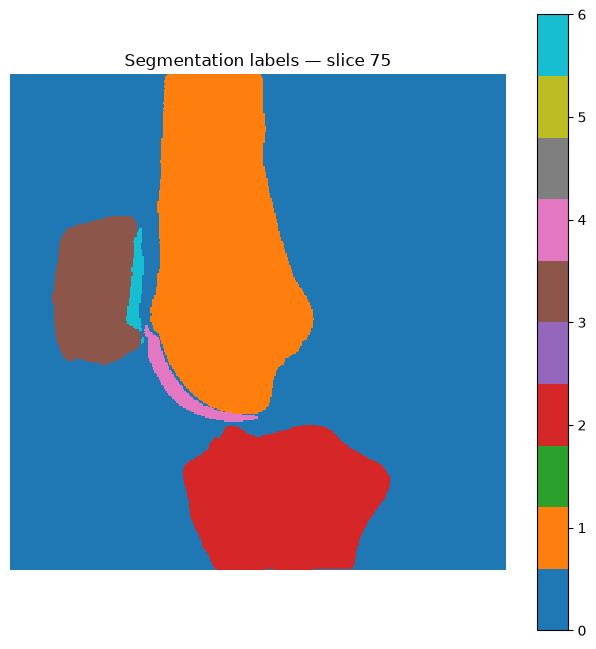

In [9]:
import matplotlib.pyplot as plt

# Middle slice
middle = x.shape[2] // 2

plt.figure(figsize=(8, 8))
plt.imshow(x[:, :, middle], cmap="tab10", interpolation="nearest")
plt.title(f"Segmentation labels — slice {middle}")
plt.colorbar()
plt.axis("off")
plt.show()

In [10]:
import os

dataset_path = r"C:\Users\asus\Downloads\OAI_Module1"

extensions = {}

for root, dirs, files in os.walk(dataset_path):
    for f in files:
        ext = os.path.splitext(f)[1].lower()
        extensions[ext] = extensions.get(ext, 0) + 1

print("File types found:")
for ext, count in sorted(extensions.items()):
    print(f"{ext or '[no extension]'} : {count}")

File types found:
.npz : 46824


In [11]:
import os

# Show the exact mask filename
mask_name = "9000099_LEFT_0.npz"

print("Mask:")
print(mask_name)

# Extract the pieces
name = mask_name.replace(".npz", "")
parts = name.split("_")

print("\nSubject ID:", parts[0])
print("Side:", parts[1])
print("Visit:", parts[2])

Mask:
9000099_LEFT_0.npz

Subject ID: 9000099
Side: LEFT
Visit: 0


In [12]:
image_dir = r"C:\Users\asus\Desktop\meddd\data\oai_samples"

print("Image/mask folder:")
print(image_dir)

Image/mask folder:
C:\Users\asus\Desktop\meddd\data\oai_samples


In [13]:
import os

# Get all files in the image/mask folder
all_files = os.listdir(image_dir)

img_files = [f for f in all_files if f.endswith("_img.png")]
mask_files = [f for f in all_files if f.endswith("_mask.png")]

print("Total files:", len(all_files))
print("Image files:", len(img_files))
print("Mask files:", len(mask_files))

print("\nFirst 10 image files:")
for f in img_files[:10]:
    print(f)

print("\nFirst 10 mask files:")
for f in mask_files[:10]:
    print(f)

Total files: 181
Image files: 60
Mask files: 60

First 10 image files:
9000099_LEFT_V00_slice010_img.png
9000099_LEFT_V00_slice059_img.png
9000099_LEFT_V00_slice123_img.png
9000296_RIGHT_V00_slice014_img.png
9000296_RIGHT_V00_slice061_img.png
9000296_RIGHT_V00_slice134_img.png
9000622_LEFT_V00_slice013_img.png
9000622_LEFT_V00_slice053_img.png
9000622_LEFT_V00_slice115_img.png
9000622_RIGHT_V00_slice035_img.png

First 10 mask files:
9000099_LEFT_V00_slice010_mask.png
9000099_LEFT_V00_slice059_mask.png
9000099_LEFT_V00_slice123_mask.png
9000296_RIGHT_V00_slice014_mask.png
9000296_RIGHT_V00_slice061_mask.png
9000296_RIGHT_V00_slice134_mask.png
9000622_LEFT_V00_slice013_mask.png
9000622_LEFT_V00_slice053_mask.png
9000622_LEFT_V00_slice115_mask.png
9000622_RIGHT_V00_slice035_mask.png


In [14]:
from PIL import Image
import numpy as np
import os

# Pick one known image
image_name = "9000099_LEFT_V00_slice059_img.png"
mask_name = "9000099_LEFT_V00_slice059_mask.png"

# Full paths
image_file = os.path.join(image_dir, image_name)
mask_file = os.path.join(image_dir, mask_name)

# Load them
image = np.array(Image.open(image_file))
mask = np.array(Image.open(mask_file))

print("IMAGE")
print("-----")
print("Shape:", image.shape)
print("Dtype:", image.dtype)
print("Min:", image.min())
print("Max:", image.max())
print("Unique values:", len(np.unique(image)))

print("\nMASK")
print("----")
print("Shape:", mask.shape)
print("Dtype:", mask.dtype)
print("Min:", mask.min())
print("Max:", mask.max())
print("Unique values:", np.unique(mask))

IMAGE
-----
Shape: (256, 256)
Dtype: uint8
Min: 0
Max: 255
Unique values: 8

MASK
----
Shape: (256, 256)
Dtype: uint8
Min: 0
Max: 255
Unique values: [  0 255]


In [15]:
print("IMAGE UNIQUE VALUES")
print(np.unique(image))

print("\nMASK UNIQUE VALUES")
print(np.unique(mask))

print("\nMASK PIXEL COUNTS")
for value in np.unique(mask):
    count = np.sum(mask == value)
    percentage = 100 * count / mask.size
    print(f"Value {value}: {count:,} pixels ({percentage:.2f}%)")

IMAGE UNIQUE VALUES
[  0  36  72 109 145 182 218 255]

MASK UNIQUE VALUES
[  0 255]

MASK PIXEL COUNTS
Value 0: 65,410 pixels (99.81%)
Value 255: 126 pixels (0.19%)


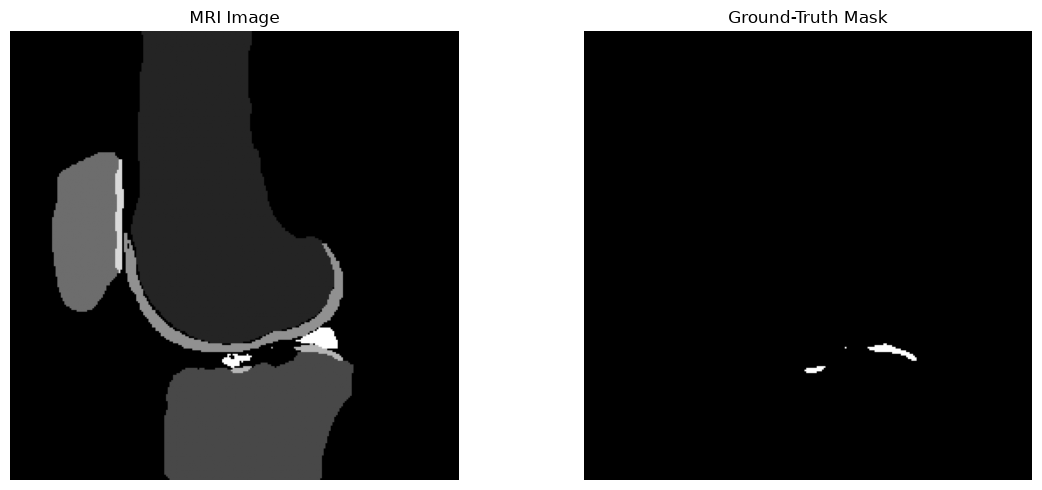

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground-Truth Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
import os
import numpy as np
from PIL import Image

foreground_percentages = []

for filename in mask_files:
    mask_path = os.path.join(image_dir, filename)
    m = np.array(Image.open(mask_path))

    foreground = np.sum(m == 255)
    percentage = 100 * foreground / m.size

    foreground_percentages.append(percentage)

print("Number of masks:", len(foreground_percentages))
print("Minimum foreground:", min(foreground_percentages), "%")
print("Maximum foreground:", max(foreground_percentages), "%")
print("Average foreground:", np.mean(foreground_percentages), "%")
print("Median foreground:", np.median(foreground_percentages), "%")

print("\nMasks with foreground > 0:")
print(sum(p > 0 for p in foreground_percentages))

print("\nMasks with foreground > 1%:")
print(sum(p > 1 for p in foreground_percentages))

Number of masks: 60
Minimum foreground: 0.00152587890625 %
Maximum foreground: 0.250244140625 %
Average foreground: 0.0788116455078125 %
Median foreground: 0.0701904296875 %

Masks with foreground > 0:
60

Masks with foreground > 1%:
0


In [18]:
import numpy as np

# Original 3D segmentation
npz_mask = data["x"]

# Slice corresponding to slice059
slice_index = 59
npz_slice = npz_mask[:, :, slice_index]

print("NPZ slice:", slice_index)
print("Shape:", npz_slice.shape)
print("Unique labels:", np.unique(npz_slice))

print("\nPixels belonging to each label:")
for label in range(8):
    count = np.sum(npz_slice == label)
    percentage = 100 * count / npz_slice.size
    print(f"Label {label}: {count:,} pixels ({percentage:.3f}%)")

print("\nPNG mask:")
print("Shape:", mask.shape)
print("Foreground pixels:", np.sum(mask == 255))
print("Foreground percentage:",
      100 * np.sum(mask == 255) / mask.size)

NPZ slice: 59
Shape: (364, 364)
Unique labels: [0 1 2 3 4 5 6 7]

Pixels belonging to each label:
Label 0: 82,878 pixels (62.551%)
Label 1: 27,536 pixels (20.783%)
Label 2: 12,975 pixels (9.793%)
Label 3: 5,680 pixels (4.287%)
Label 4: 2,174 pixels (1.641%)
Label 5: 255 pixels (0.192%)
Label 6: 491 pixels (0.371%)
Label 7: 507 pixels (0.383%)

PNG mask:
Shape: (256, 256)
Foreground pixels: 126
Foreground percentage: 0.1922607421875


In [19]:
from PIL import Image
import numpy as np

# Resize the original NPZ label slice to PNG size
npz_resized = np.array(
    Image.fromarray(npz_slice).resize(
        (256, 256),
        resample=Image.Resampling.NEAREST
    )
)

# PNG binary mask
png_binary = (mask == 255)

print("Comparison with each NPZ label")
print("=" * 40)

for label in range(8):

    npz_binary = (npz_resized == label)

    intersection = np.logical_and(
        npz_binary,
        png_binary
    ).sum()

    union = np.logical_or(
        npz_binary,
        png_binary
    ).sum()

    if union > 0:
        iou = intersection / union
    else:
        iou = 0

    print(f"Label {label}: IoU = {iou:.4f}")

Comparison with each NPZ label
Label 0: IoU = 0.0001
Label 1: IoU = 0.0000
Label 2: IoU = 0.0026
Label 3: IoU = 0.0000
Label 4: IoU = 0.0000
Label 5: IoU = 0.7123
Label 6: IoU = 0.0000
Label 7: IoU = 0.0000


In [20]:
import os

# Extract subject IDs from the image filenames
subject_ids = []

for filename in img_files:
    subject_id = filename.split("_")[0]
    subject_ids.append(subject_id)

unique_subjects = sorted(set(subject_ids))

print("Total image slices:", len(img_files))
print("Unique subjects:", len(unique_subjects))

print("\nSubjects:")
for subject in unique_subjects:
    count = subject_ids.count(subject)
    print(subject, "->", count, "slices")

Total image slices: 60
Unique subjects: 11

Subjects:
9000099 -> 3 slices
9000296 -> 3 slices
9000622 -> 6 slices
9000798 -> 6 slices
9001104 -> 6 slices
9001400 -> 6 slices
9001695 -> 6 slices
9001897 -> 6 slices
9002116 -> 6 slices
9002316 -> 6 slices
9002411 -> 6 slices


In [21]:
import random

# Make the split reproducible
random.seed(42)

subjects = unique_subjects.copy()
random.shuffle(subjects)

# Split subjects
train_subjects = subjects[:8]
val_subjects = subjects[8:10]
test_subjects = subjects[10:]

print("TRAIN SUBJECTS:")
print(train_subjects)

print("\nVALIDATION SUBJECTS:")
print(val_subjects)

print("\nTEST SUBJECTS:")
print(test_subjects)

# Create image lists for each split
train_images = [
    f for f in img_files
    if f.split("_")[0] in train_subjects
]

val_images = [
    f for f in img_files
    if f.split("_")[0] in val_subjects
]

test_images = [
    f for f in img_files
    if f.split("_")[0] in test_subjects
]

print("\nNumber of slices:")
print("Train:", len(train_images))
print("Validation:", len(val_images))
print("Test:", len(test_images))

TRAIN SUBJECTS:
['9001897', '9000798', '9000622', '9002116', '9001400', '9001695', '9002316', '9001104']

VALIDATION SUBJECTS:
['9000099', '9000296']

TEST SUBJECTS:
['9002411']

Number of slices:
Train: 48
Validation: 6
Test: 6


In [22]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import os


class OAISegmentationDataset(Dataset):

    def __init__(self, image_filenames, image_dir):
        self.image_filenames = image_filenames
        self.image_dir = image_dir

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, index):

        image_name = self.image_filenames[index]

        # Corresponding mask filename
        mask_name = image_name.replace("_img.png", "_mask.png")

        # Full paths
        image_path = os.path.join(self.image_dir, image_name)
        mask_path = os.path.join(self.image_dir, mask_name)

        # Load image
        image = np.array(
            Image.open(image_path),
            dtype=np.float32
        )

        # Load mask
        mask = np.array(
            Image.open(mask_path),
            dtype=np.float32
        )

        # Normalize image: 0-255 -> 0-1
        image = image / 255.0

        # Convert mask: 0/255 -> 0/1
        mask = (mask > 0).astype(np.float32)

        # Add channel dimension
        image = torch.from_numpy(image).unsqueeze(0)
        mask = torch.from_numpy(mask).unsqueeze(0)

        return image, mask


print("Dataset class created successfully.")

Dataset class created successfully.


In [23]:
# Create the training dataset
train_dataset = OAISegmentationDataset(
    train_images,
    image_dir
)

print("Training samples:", len(train_dataset))

# Load the first sample
image_tensor, mask_tensor = train_dataset[0]

print("\nImage tensor:")
print("Shape:", image_tensor.shape)
print("Dtype:", image_tensor.dtype)
print("Min:", image_tensor.min().item())
print("Max:", image_tensor.max().item())

print("\nMask tensor:")
print("Shape:", mask_tensor.shape)
print("Dtype:", mask_tensor.dtype)
print("Min:", mask_tensor.min().item())
print("Max:", mask_tensor.max().item())
print("Unique values:", torch.unique(mask_tensor))

Training samples: 48

Image tensor:
Shape: torch.Size([1, 256, 256])
Dtype: torch.float32
Min: 0.0
Max: 1.0

Mask tensor:
Shape: torch.Size([1, 256, 256])
Dtype: torch.float32
Min: 0.0
Max: 1.0
Unique values: tensor([0., 1.])


In [24]:
# Create validation and test datasets
val_dataset = OAISegmentationDataset(
    val_images,
    image_dir
)

test_dataset = OAISegmentationDataset(
    test_images,
    image_dir
)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

print("DataLoaders created successfully.")

print("\nDataset sizes:")
print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

print("\nNumber of batches:")
print("Training:", len(train_loader))
print("Validation:", len(val_loader))
print("Test:", len(test_loader))

DataLoaders created successfully.

Dataset sizes:
Training: 48
Validation: 6
Test: 6

Number of batches:
Training: 12
Validation: 2
Test: 2


In [25]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(1, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        # Decoder
        self.up3 = nn.ConvTranspose2d(
            256, 128, kernel_size=2, stride=2
        )
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(
            128, 64, kernel_size=2, stride=2
        )
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(
            64, 32, kernel_size=2, stride=2
        )
        self.dec1 = DoubleConv(64, 32)

        # Final output
        self.out = nn.Conv2d(
            32, 1, kernel_size=1
        )

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        # Bottleneck
        b = self.bottleneck(self.pool(e3))

        # Decoder
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)


print("U-Net class created successfully.")

U-Net class created successfully.


In [26]:
# Select CPU because CUDA is not available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# Create U-Net
model = UNet().to(device)

# Get one batch
images, masks = next(iter(train_loader))

print("\nInput batch:")
print("Images:", images.shape)
print("Masks:", masks.shape)

# Move images to the device
images = images.to(device)

# Forward pass
with torch.no_grad():
    outputs = model(images)

print("\nModel output:")
print("Shape:", outputs.shape)
print("Dtype:", outputs.dtype)

Device: cpu

Input batch:
Images: torch.Size([4, 1, 256, 256])
Masks: torch.Size([4, 1, 256, 256])

Model output:
Shape: torch.Size([4, 1, 256, 256])
Dtype: torch.float32


In [27]:
import torch
import torch.nn as nn


# Binary Cross Entropy + Dice loss
class BCEDiceLoss(nn.Module):

    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):

        # BCE
        bce_loss = self.bce(logits, targets)

        # Convert logits to probabilities
        probabilities = torch.sigmoid(logits)

        # Flatten
        probabilities = probabilities.view(probabilities.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        # Dice
        intersection = (probabilities * targets).sum(dim=1)

        dice = (
            (2.0 * intersection + 1.0)
            /
            (probabilities.sum(dim=1) + targets.sum(dim=1) + 1.0)
        )

        dice_loss = 1.0 - dice.mean()

        return bce_loss + dice_loss


# Create loss function
criterion = BCEDiceLoss()

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: BCEDiceLoss(
  (bce): BCEWithLogitsLoss()
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [28]:
def dice_score(logits, targets, threshold=0.5):
    """
    Calculate Dice score for binary segmentation.
    """

    probabilities = torch.sigmoid(logits)
    predictions = (probabilities > threshold).float()

    predictions = predictions.view(predictions.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (predictions * targets).sum(dim=1)

    dice = (
        (2.0 * intersection + 1.0)
        /
        (predictions.sum(dim=1) + targets.sum(dim=1) + 1.0)
    )

    return dice.mean().item()


def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    total_loss = 0.0
    total_dice = 0.0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, masks)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        total_loss += loss.item()
        total_dice += dice_score(outputs.detach(), masks)

    average_loss = total_loss / len(loader)
    average_dice = total_dice / len(loader)

    return average_loss, average_dice


def validate(model, loader, criterion, device):

    model.eval()

    total_loss = 0.0
    total_dice = 0.0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            total_loss += loss.item()
            total_dice += dice_score(outputs, masks)

    average_loss = total_loss / len(loader)
    average_dice = total_dice / len(loader)

    return average_loss, average_dice


print("Training and validation functions created successfully.")

Training and validation functions created successfully.


In [29]:
num_epochs = 5

train_losses = []
val_losses = []

train_dices = []
val_dices = []

print("Starting training...")
print("Device:", device)
print("Epochs:", num_epochs)

for epoch in range(num_epochs):

    train_loss, train_dice = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_dice = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_dices.append(train_dice)
    val_dices.append(val_dice)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Dice: {train_dice:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Dice: {val_dice:.4f}"
    )

print("\nTraining complete!")

Starting training...
Device: cpu
Epochs: 5
Epoch [1/5] | Train Loss: 1.5640 | Train Dice: 0.0530 | Val Loss: 1.5723 | Val Dice: 0.0826
Epoch [2/5] | Train Loss: 1.4562 | Train Dice: 0.1582 | Val Loss: 1.4470 | Val Dice: 0.0826
Epoch [3/5] | Train Loss: 1.4021 | Train Dice: 0.3806 | Val Loss: 1.4348 | Val Dice: 0.0826
Epoch [4/5] | Train Loss: 1.3577 | Train Dice: 0.4793 | Val Loss: 1.3792 | Val Dice: 0.2274
Epoch [5/5] | Train Loss: 1.3271 | Train Dice: 0.5375 | Val Loss: 1.3157 | Val Dice: 0.4982

Training complete!


In [30]:
test_loss, test_dice = validate(
    model,
    test_loader,
    criterion,
    device
)

print("TEST RESULTS")
print("============")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Dice: {test_dice:.4f}")

TEST RESULTS
Test Loss: 1.3072
Test Dice: 0.5647


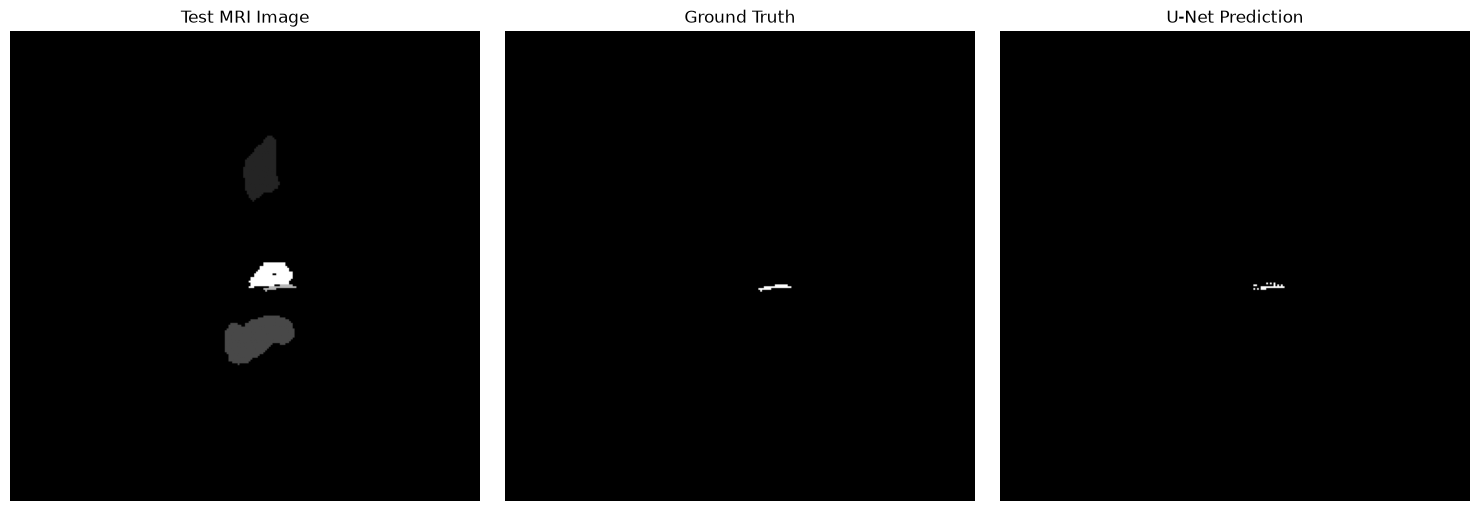

In [31]:
import matplotlib.pyplot as plt

# Get one test sample
test_image, test_mask = test_dataset[0]

# Add batch dimension and move to device
input_image = test_image.unsqueeze(0).to(device)

# Predict
model.eval()

with torch.no_grad():
    prediction_logits = model(input_image)
    prediction_probability = torch.sigmoid(prediction_logits)

# Convert prediction to binary mask
prediction_mask = (
    prediction_probability[0, 0].cpu().numpy() > 0.5
)

# Original image and ground truth
original_image = test_image[0].numpy()
ground_truth = test_mask[0].numpy()

# Plot
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_image, cmap="gray")
plt.title("Test MRI Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(ground_truth, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(prediction_mask, cmap="gray")
plt.title("U-Net Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:
# Calculate IoU on the complete test set

model.eval()

total_intersection = 0
total_union = 0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        predictions = (torch.sigmoid(outputs) > 0.5).float()

        intersection = (predictions * masks).sum().item()
        union = ((predictions + masks) > 0).float().sum().item()

        total_intersection += intersection
        total_union += union

test_iou = total_intersection / (total_union + 1e-8)

print("TEST IoU")
print("========")
print(f"Test IoU: {test_iou:.4f}")

TEST IoU
Test IoU: 0.3834


In [33]:
# Save the trained U-Net model

model_path = r"C:\Users\asus\Desktop\meddd\data\oai_unet_model.pth"

torch.save(model.state_dict(), model_path)

print("Model saved successfully!")
print("Path:", model_path)

Model saved successfully!
Path: C:\Users\asus\Desktop\meddd\data\oai_unet_model.pth


In [34]:
import os

print("Exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("Model size:", os.path.getsize(model_path) / (1024 * 1024), "MB")

Exists: True
Model size: 7.397944450378418 MB


In [35]:
# Create a fresh U-Net
test_model = UNet().to(device)

# Load the saved trained weights
test_model.load_state_dict(
    torch.load(model_path, map_location=device)
)

# Evaluation mode
test_model.eval()

print("Saved model loaded successfully!")

Saved model loaded successfully!


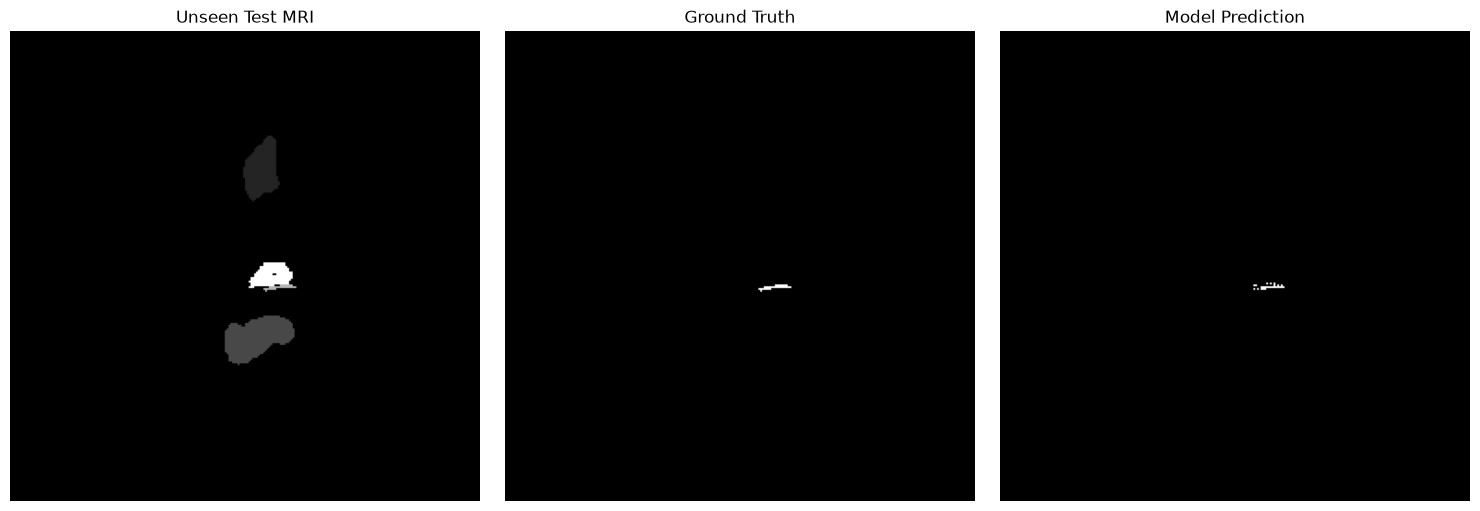

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Take one completely unseen test sample
test_image, test_mask = test_dataset[0]

# Add batch dimension
input_image = test_image.unsqueeze(0).to(device)

# Prediction
with torch.no_grad():
    output = test_model(input_image)
    probability = torch.sigmoid(output)

# Convert probability to binary prediction
predicted_mask = (probability[0, 0].cpu().numpy() > 0.5).astype(np.uint8)

# Get original image and ground truth
original_image = test_image[0].numpy()
ground_truth = test_mask[0].numpy()

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_image, cmap="gray")
plt.title("Unseen Test MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(ground_truth, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(predicted_mask, cmap="gray")
plt.title("Model Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

In [37]:
# Calculate Dice and IoU for this individual test image

prediction = predicted_mask.astype(bool)
truth = ground_truth.astype(bool)

intersection = np.logical_and(prediction, truth).sum()
union = np.logical_or(prediction, truth).sum()

dice = (2 * intersection) / (
    prediction.sum() + truth.sum() + 1e-8
)

iou = intersection / (union + 1e-8)

print("INDIVIDUAL TEST IMAGE")
print("=====================")
print(f"Dice: {dice:.4f}")
print(f"IoU:  {iou:.4f}")

INDIVIDUAL TEST IMAGE
Dice: 0.7500
IoU:  0.6000


In [38]:
# Evaluate the SAVED model on the complete unseen test set

test_loss, test_dice = validate(
    test_model,
    test_loader,
    criterion,
    device
)

print("SAVED MODEL TEST")
print("================")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Dice: {test_dice:.4f}")

SAVED MODEL TEST
Test Loss: 1.3072
Test Dice: 0.5647


In [39]:
total_intersection = 0
total_union = 0

test_model.eval()

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = test_model(images)

        predictions = (
            torch.sigmoid(outputs) > 0.5
        ).float()

        intersection = (
            predictions * masks
        ).sum().item()

        union = (
            ((predictions + masks) > 0)
            .float()
            .sum()
            .item()
        )

        total_intersection += intersection
        total_union += union

saved_model_iou = (
    total_intersection /
    (total_union + 1e-8)
)

print(f"Test IoU: {saved_model_iou:.4f}")

Test IoU: 0.3834


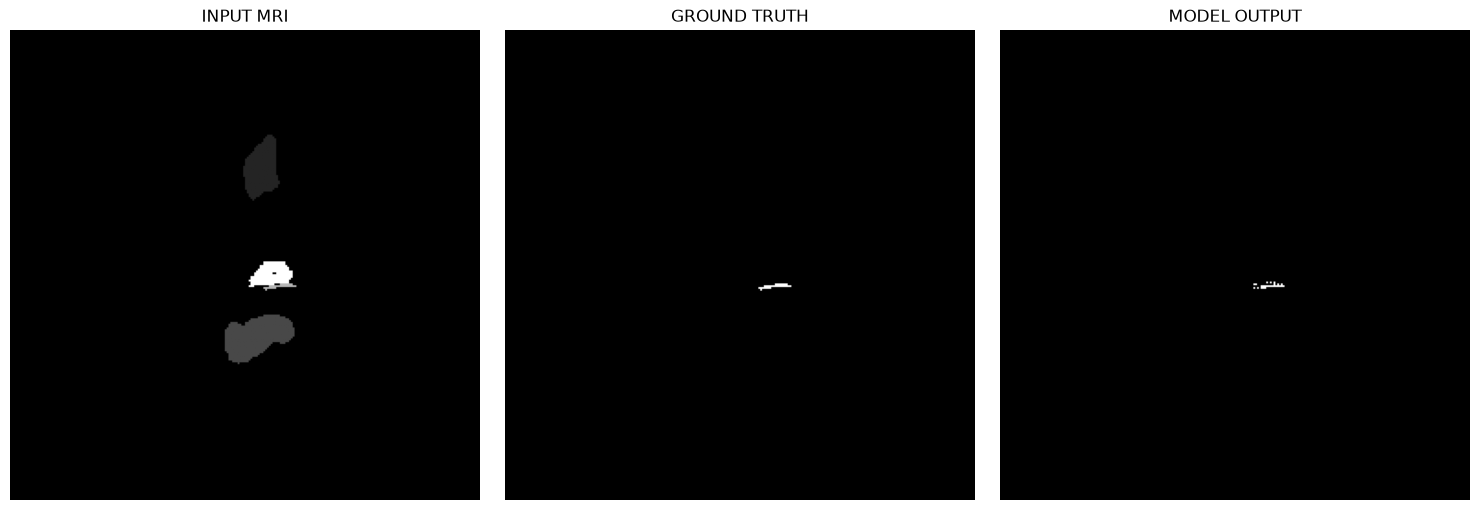

In [40]:
import matplotlib.pyplot as plt
import torch

# Take one unseen test image
test_image, test_mask = test_dataset[0]

# Send image to model
input_image = test_image.unsqueeze(0).to(device)

# Make prediction
test_model.eval()

with torch.no_grad():
    output = test_model(input_image)
    probability = torch.sigmoid(output)

# Convert prediction to binary mask
prediction = (probability[0, 0].cpu().numpy() > 0.5)

# Convert tensors to images
image = test_image[0].numpy()
ground_truth = test_mask[0].numpy()

# Display everything
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("INPUT MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(ground_truth, cmap="gray")
plt.title("GROUND TRUTH")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(prediction, cmap="gray")
plt.title("MODEL OUTPUT")
plt.axis("off")

plt.tight_layout()
plt.show()

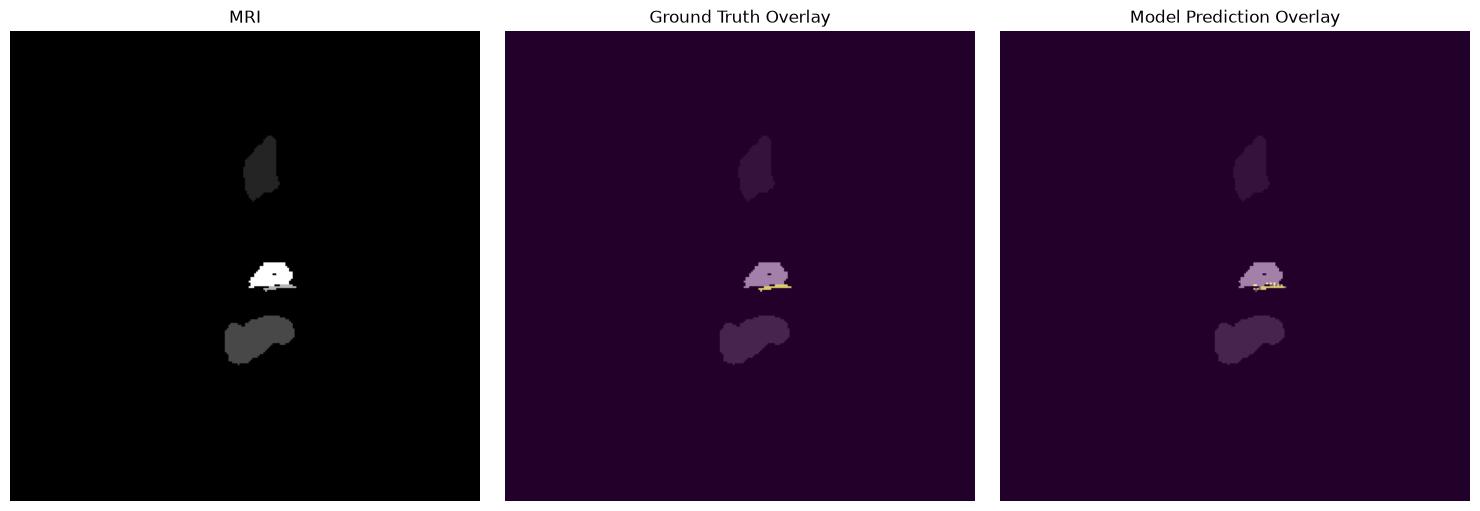

In [41]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(image, cmap="gray")
plt.imshow(ground_truth, alpha=0.5)
plt.title("Ground Truth Overlay")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image, cmap="gray")
plt.imshow(prediction, alpha=0.5)
plt.title("Model Prediction Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [43]:
from PIL import Image

image_path = r"C:\Users\asus\Desktop\meddd\data\oai_samples\9000099_LEFT_V00_slice059_img.png

img = Image.open(image_path)

print("Image loaded successfully!")
print("Image size:", img.size)

SyntaxError: unterminated string literal (detected at line 3) (3623475876.py, line 3)

In [44]:
from PIL import Image

image_path = r"C:\Users\asus\Desktop\meddd\data\oai_samples\9000099_LEFT_V00_slice059_img.png

img = Image.open(image_path)

print("Image loaded successfully!")
print("Image size:", img.size)

SyntaxError: unterminated string literal (detected at line 3) (3623475876.py, line 3)

In [45]:
from PIL import Image

image_path = r"C:\Users\asus\Desktop\meddd\data\oai_samples\9000099_LEFT_V00_slice059_img.png"

img = Image.open(image_path)

print("Image loaded successfully!")
print("Image size:", img.size)

Image loaded successfully!
Image size: (256, 256)


In [46]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Convert the image to numpy
img_array = np.array(img)

# Convert 0-255 to 0-1
img_normalized = img_array.astype(np.float32) / 255.0

# Create tensor: [batch, channel, height, width]
input_tensor = torch.tensor(img_normalized).unsqueeze(0).unsqueeze(0)

# Put image on the same device as the model
input_tensor = input_tensor.to(device)

# Run the trained model
model.eval()

with torch.no_grad():
    output = model(input_tensor)
    prediction = torch.sigmoid(output)

# Convert prediction to binary mask
pred_mask = (prediction > 0.5).float()

print("Input shape:", input_tensor.shape)
print("Prediction shape:", pred_mask.shape)
print("Foreground pixels:", int(pred_mask.sum().item()))

Input shape: torch.Size([1, 1, 256, 256])
Prediction shape: torch.Size([1, 1, 256, 256])
Foreground pixels: 232


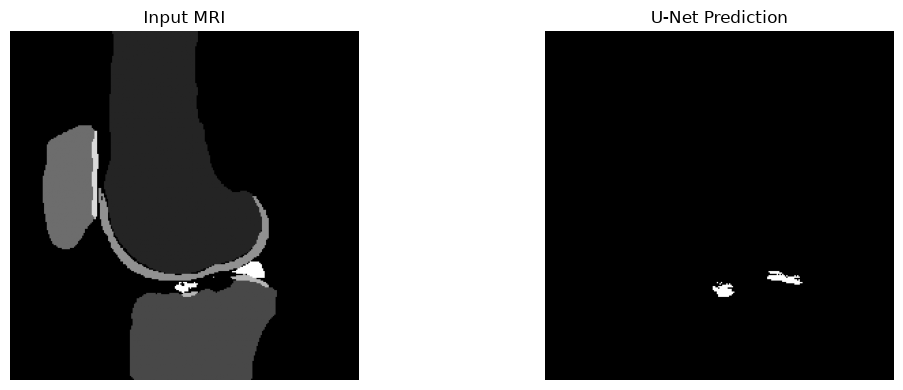

In [47]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_array, cmap="gray")
plt.title("Input MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pred_mask[0, 0].cpu().numpy(), cmap="gray")
plt.title("U-Net Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

In [48]:
from PIL import Image
import numpy as np

image_path = r"C:\Users\asus\Downloads\test-img.jpg"

img = Image.open(image_path).convert("L")

print("Image loaded successfully!")
print("Image size:", img.size)
print("Image mode:", img.mode)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\asus\\Downloads\\test-img.jpg'

In [49]:
import os

print(os.listdir(r"C:\Users\asus\Downloads"))

['....jpg', '0123.mp4', '1. அறிமுகம் காஸ்ட் (Cast) என்பது உடைந்த எலும்பு அல்லது காயமடைந்த உறுப்பை அசையாமல் வைத்திருக்க பயன்படுத்தப்படும் கடினமான கட்டுப்பாடு ஆகும். இது பொதுவாக பிளாஸ்டர் ஆஃப் பாரிஸ் (POP) அல்லது ஃபைபர் கா.pptx', '1. அறிமுகம் காஸ்ட் (Cast) என்பது உடைந்த எலும்பு அல்லது காயமடைந்த உறுப்பை அசையாமல் வைத்திருக்க பயன்படுத்தப்படும் கடினமான கட்டுப்பாடு ஆகும். இது பொதுவாக பிளாஸ்டர் ஆஃப் பாரிஸ் (POP) அல்லது ஃபைபர் காஸ (1).pdf', '1. அறிமுகம் காஸ்ட் (Cast) என்பது உடைந்த எலும்பு அல்லது காயமடைந்த உறுப்பை அசையாமல் வைத்திருக்க பயன்படுத்தப்படும் கடினமான கட்டுப்பாடு ஆகும். இது பொதுவாக பிளாஸ்டர் ஆஃப் பாரிஸ் (POP) அல்லது ஃபைபர் காஸ.pdf', '2025-08-14 16_47_25.210878_swetha.settu2675@gmail.com.pdf', '2343_3_1283699_1761729507_Databricks - Generic.pdf', '2390_3_1283699_1761730181_Databricks - Generic.pdf', '2395_3_1283699_1761730717_Databricks - Generic.pdf', '23ITT204_CN_IA_2_QB_with_answers (1).pdf', '23ITT204_CN_IA_2_QB_with_answers.pdf', '23MAT204-FOPS (1).pdf', '23MAT204-FOPS.pdf', '2400_3

In [50]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

# Your test image
image_path = r"C:\Users\asus\Downloads\knee-mri.jpg"

# Load image
img = Image.open(image_path).convert("L")

print("Image loaded successfully!")
print("Original size:", img.size)

# Resize exactly like training
img_resized = img.resize((256, 256))

# Convert to numpy
img_array = np.array(img_resized).astype(np.float32) / 255.0

# Convert to PyTorch tensor
image_tensor = torch.from_numpy(img_array).unsqueeze(0).unsqueeze(0)

print("Tensor shape:", image_tensor.shape)
print("Tensor dtype:", image_tensor.dtype)

Image loaded successfully!
Original size: (630, 630)
Tensor shape: torch.Size([1, 1, 256, 256])
Tensor dtype: torch.float32


In [51]:
model.eval()

with torch.no_grad():
    image_tensor = image_tensor.to(device)
    
    output = model(image_tensor)
    
    prediction = torch.sigmoid(output)
    prediction = (prediction > 0.5).float()

print("Prediction shape:", prediction.shape)
print("Prediction foreground pixels:",
      prediction.sum().item())

Prediction shape: torch.Size([1, 1, 256, 256])
Prediction foreground pixels: 0.0


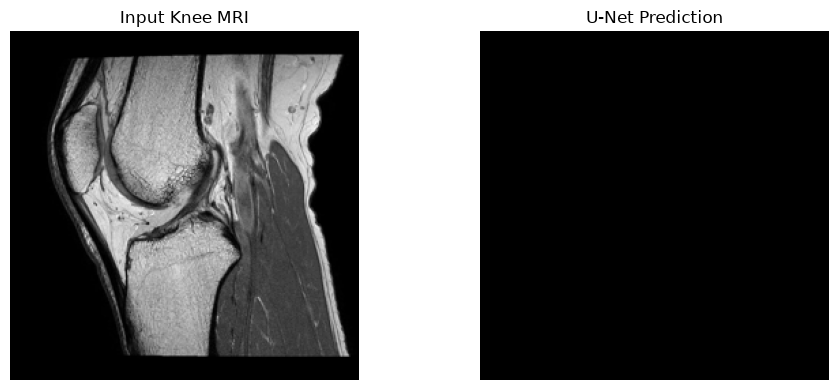

In [52]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_resized, cmap="gray")
plt.title("Input Knee MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(prediction[0, 0].cpu().numpy(), cmap="gray")
plt.title("U-Net Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

In [53]:
print("Prediction min:", prediction.min().item())
print("Prediction max:", prediction.max().item())
print("Prediction mean:", prediction.mean().item())
print("Foreground pixels:", prediction.sum().item())

Prediction min: 0.0
Prediction max: 0.0
Prediction mean: 0.0
Foreground pixels: 0.0


In [54]:
probability = torch.sigmoid(output)

print("Probability min:", probability.min().item())
print("Probability max:", probability.max().item())
print("Probability mean:", probability.mean().item())

Probability min: 0.040534764528274536
Probability max: 0.4271562099456787
Probability mean: 0.1877693086862564


In [55]:
prediction = (probability > 0.5).float()

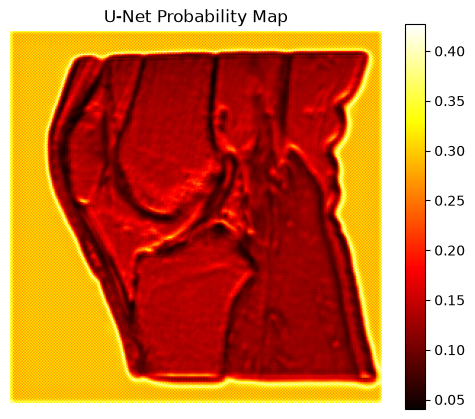

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(probability[0, 0].cpu().numpy(), cmap="hot")
plt.colorbar()
plt.title("U-Net Probability Map")
plt.axis("off")
plt.show()

In [57]:
for threshold in [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]:
    pred = (probability > threshold).float()
    pixels = pred.sum().item()
    print(f"Threshold {threshold}: {pixels:.0f} foreground pixels")

Threshold 0.1: 58225 foreground pixels
Threshold 0.15: 28947 foreground pixels
Threshold 0.2: 24071 foreground pixels
Threshold 0.25: 23165 foreground pixels
Threshold 0.3: 12978 foreground pixels
Threshold 0.4: 282 foreground pixels
Threshold 0.5: 0 foreground pixels


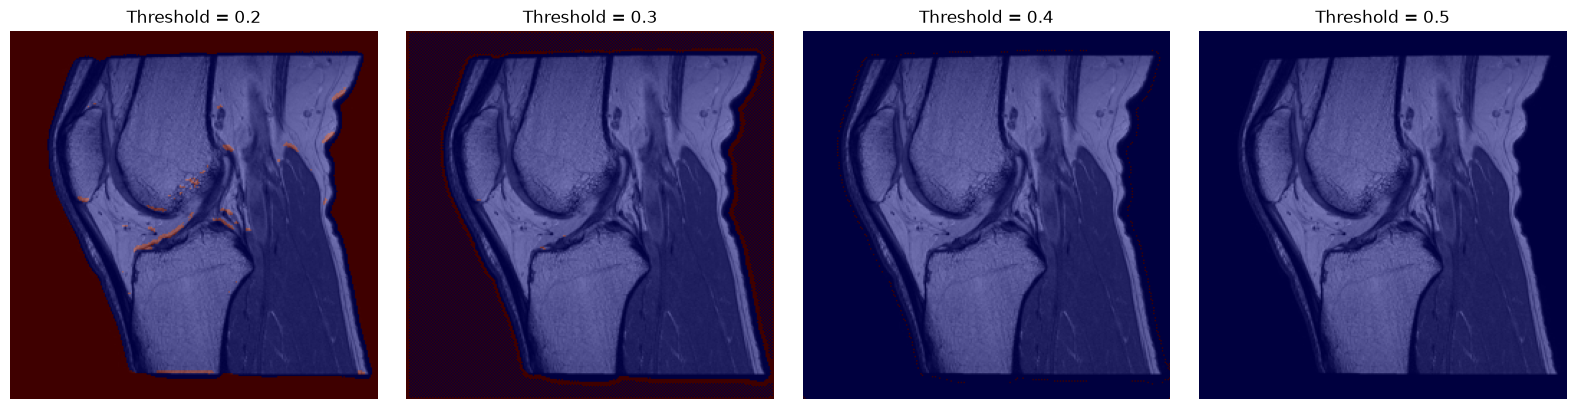

In [58]:
import matplotlib.pyplot as plt

img_np = np.array(img_resized)

thresholds = [0.2, 0.3, 0.4, 0.5]

plt.figure(figsize=(16, 4))

for i, threshold in enumerate(thresholds):
    pred = (probability[0, 0].cpu().numpy() > threshold)

    plt.subplot(1, 4, i + 1)
    plt.imshow(img_np, cmap="gray")
    plt.imshow(pred, cmap="jet", alpha=0.5)
    plt.title(f"Threshold = {threshold}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [59]:
# Pick one test image
test_image_path = r"C:\Users\asus\Desktop\meddd\data\oai_samples\9002411_RIGHT_V00_slice016_img.png"

# Corresponding ground-truth mask
test_mask_path = r"C:\Users\asus\Desktop\meddd\data\oai_samples\9002411_RIGHT_V00_slice016_mask.png"

print("Test image:", test_image_path)
print("Test mask:", test_mask_path)

Test image: C:\Users\asus\Desktop\meddd\data\oai_samples\9002411_RIGHT_V00_slice016_img.png
Test mask: C:\Users\asus\Desktop\meddd\data\oai_samples\9002411_RIGHT_V00_slice016_mask.png


In [60]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

# Test image and ground-truth mask
test_image_path = r"C:\Users\asus\Desktop\meddd\data\oai_samples\9002411_RIGHT_V00_slice016_img.png"
test_mask_path = r"C:\Users\asus\Desktop\meddd\data\oai_samples\9002411_RIGHT_V00_slice016_mask.png"

# Load image
test_img = Image.open(test_image_path).convert("L")
test_mask = Image.open(test_mask_path).convert("L")

# Resize to the same size used during training
test_img = test_img.resize((256, 256))
test_mask = test_mask.resize((256, 256))

# Convert image to [0, 1]
test_img_np = np.array(test_img).astype(np.float32) / 255.0

# Convert mask to binary [0, 1]
test_mask_np = (np.array(test_mask) > 0).astype(np.float32)

# Create tensor
test_tensor = torch.from_numpy(test_img_np).unsqueeze(0).unsqueeze(0)

# Send to CPU/GPU
test_tensor = test_tensor.to(device)

# Model prediction
model.eval()

with torch.no_grad():
    output = model(test_tensor)
    probability = torch.sigmoid(output)
    prediction = (probability > 0.5).float()

# Convert prediction back to numpy
prediction_np = prediction[0, 0].cpu().numpy()

print("Test image shape:", test_img_np.shape)
print("Ground-truth foreground pixels:", int(test_mask_np.sum()))
print("Predicted foreground pixels:", int(prediction_np.sum()))
print("Maximum probability:", probability.max().item())

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\asus\\Desktop\\meddd\\data\\oai_samples\\9002411_RIGHT_V00_slice016_img.png'

In [61]:
import os

folder = r"C:\Users\asus\Desktop\meddd\data\oai_samples"

files_9002411 = [
    f for f in os.listdir(folder)
    if f.startswith("9002411")
]

print("Files for 9002411:")
for f in files_9002411:
    print(f)

Files for 9002411:
9002411_LEFT_V00_slice009.png
9002411_LEFT_V00_slice010_img.png
9002411_LEFT_V00_slice010_mask.png
9002411_LEFT_V00_slice060_img.png
9002411_LEFT_V00_slice060_mask.png
9002411_LEFT_V00_slice071.png
9002411_LEFT_V00_slice127_img.png
9002411_LEFT_V00_slice127_mask.png
9002411_LEFT_V00_slice134.png
9002411_RIGHT_V00_slice012.png
9002411_RIGHT_V00_slice018_img.png
9002411_RIGHT_V00_slice018_mask.png
9002411_RIGHT_V00_slice074.png
9002411_RIGHT_V00_slice085_img.png
9002411_RIGHT_V00_slice085_mask.png
9002411_RIGHT_V00_slice136_img.png
9002411_RIGHT_V00_slice136_mask.png
9002411_RIGHT_V00_slice137.png


In [62]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

# Exact files that exist
test_image_path = r"C:\Users\asus\Desktop\meddd\data\oai_samples\9002411_RIGHT_V00_slice018_img.png"
test_mask_path = r"C:\Users\asus\Desktop\meddd\data\oai_samples\9002411_RIGHT_V00_slice018_mask.png"

# Load
test_img = Image.open(test_image_path).convert("L")
test_mask = Image.open(test_mask_path).convert("L")

print("Image loaded:", test_img.size)
print("Mask loaded:", test_mask.size)

# Resize exactly like training
test_img = test_img.resize((256, 256))
test_mask = test_mask.resize((256, 256))

# Convert image to 0-1
test_img_np = np.array(test_img).astype(np.float32) / 255.0

# Convert mask to binary
test_mask_np = (np.array(test_mask) > 0).astype(np.float32)

# Create tensor
test_tensor = torch.from_numpy(test_img_np).unsqueeze(0).unsqueeze(0)

print("Tensor shape:", test_tensor.shape)
print("Ground-truth foreground pixels:", int(test_mask_np.sum()))

Image loaded: (256, 256)
Mask loaded: (256, 256)
Tensor shape: torch.Size([1, 1, 256, 256])
Ground-truth foreground pixels: 28


In [63]:
model.eval()

test_tensor = test_tensor.to(device)

with torch.no_grad():
    output = model(test_tensor)
    probability = torch.sigmoid(output)
    prediction = (probability > 0.5).float()

prediction_np = prediction[0, 0].cpu().numpy()

print("Maximum probability:", probability.max().item())
print("Mean probability:", probability.mean().item())
print("Predicted foreground pixels:", int(prediction_np.sum()))

Maximum probability: 0.7210620641708374
Mean probability: 0.2790478467941284
Predicted foreground pixels: 68


In [64]:
gt = test_mask_np.flatten()
pred = prediction_np.flatten()

intersection = np.sum(gt * pred)

dice = (2 * intersection + 1e-8) / (
    np.sum(gt) + np.sum(pred) + 1e-8
)

union = np.sum(gt) + np.sum(pred) - intersection

iou = (intersection + 1e-8) / (union + 1e-8)

print("================================")
print("SINGLE TEST IMAGE RESULTS")
print("================================")
print(f"Dice: {dice:.4f}")
print(f"IoU : {iou:.4f}")

SINGLE TEST IMAGE RESULTS
Dice: 0.5625
IoU : 0.3913


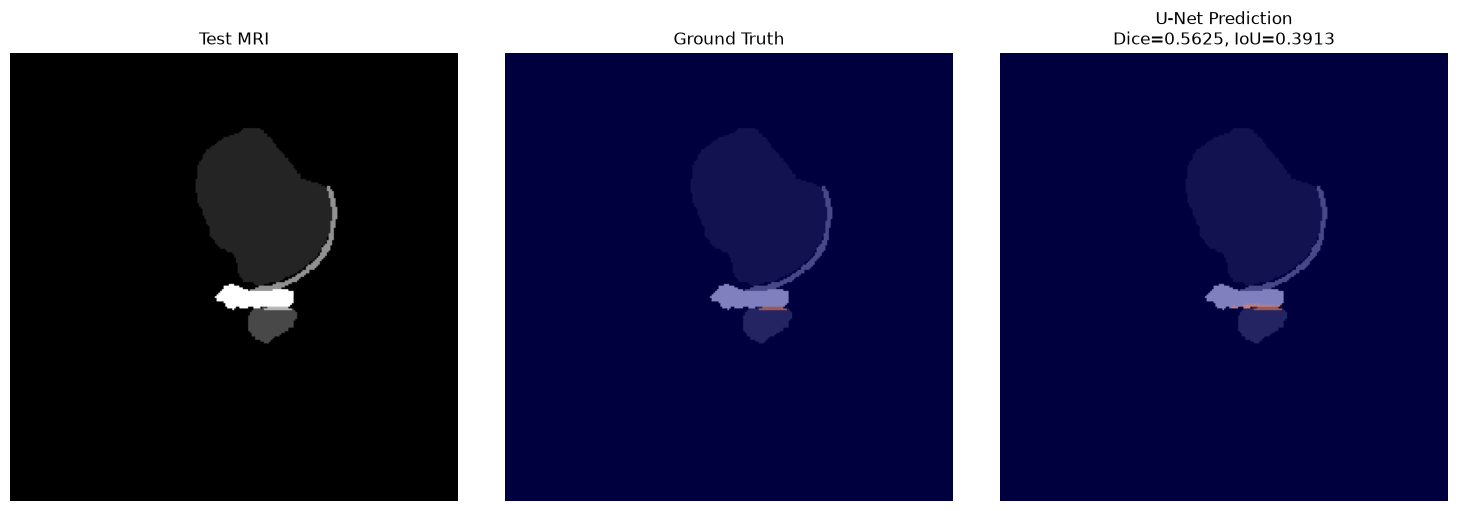

In [65]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(test_img_np, cmap="gray")
plt.title("Test MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(test_img_np, cmap="gray")
plt.imshow(test_mask_np, cmap="jet", alpha=0.5)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(test_img_np, cmap="gray")
plt.imshow(prediction_np, cmap="jet", alpha=0.5)
plt.title(f"U-Net Prediction\nDice={dice:.4f}, IoU={iou:.4f}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [66]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch

test_image_path = r"C:\Users\asus\Desktop\meddd\data\oai_samples\9002411_RIGHT_V00_slice018_img.png"
test_mask_path = r"C:\Users\asus\Desktop\meddd\data\oai_samples\9002411_RIGHT_V00_slice018_mask.png"

test_img = Image.open(test_image_path).convert("L")
test_mask = Image.open(test_mask_path).convert("L")

print("Image size:", test_img.size)
print("Mask size:", test_mask.size)

Image size: (256, 256)
Mask size: (256, 256)


In [67]:
test_img_np = np.array(test_img).astype(np.float32) / 255.0

test_mask_np = np.array(test_mask).astype(np.float32) / 255.0

print("Image:")
print("Shape:", test_img_np.shape)
print("Min:", test_img_np.min())
print("Max:", test_img_np.max())

print("\nMask:")
print("Shape:", test_mask_np.shape)
print("Unique:", np.unique(test_mask_np))

Image:
Shape: (256, 256)
Min: 0.0
Max: 1.0

Mask:
Shape: (256, 256)
Unique: [0. 1.]


In [68]:
image_tensor = torch.from_numpy(test_img_np).unsqueeze(0).unsqueeze(0)

print("Tensor shape:", image_tensor.shape)

Tensor shape: torch.Size([1, 1, 256, 256])


In [69]:
model.eval()

UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential

In [70]:
device = torch.device("cpu")
model = model.to(device)

In [71]:
image_tensor = image_tensor.to(device)

with torch.no_grad():
    output = model(image_tensor)

print("Model output shape:", output.shape)

Model output shape: torch.Size([1, 1, 256, 256])


In [72]:
probability = torch.sigmoid(output)

print("Probability min:", probability.min().item())
print("Probability max:", probability.max().item())
print("Probability mean:", probability.mean().item())

Probability min: 0.05177021399140358
Probability max: 0.7210620641708374
Probability mean: 0.2790478467941284


In [73]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    pred = (probability[0, 0].cpu().numpy() > threshold).astype(np.uint8)

    print(
        f"Threshold {threshold:.1f}: "
        f"{pred.sum()} foreground pixels"
    )

Threshold 0.2: 59483 foreground pixels
Threshold 0.3: 30515 foreground pixels
Threshold 0.4: 243 foreground pixels
Threshold 0.5: 68 foreground pixels
Threshold 0.6: 18 foreground pixels
Threshold 0.7: 1 foreground pixels


In [74]:
gt = test_mask_np.astype(bool)

thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

print("THRESHOLD RESULTS")
print("=================")

best_dice = -1
best_threshold = None

for threshold in thresholds:

    pred = (
        probability[0, 0].cpu().numpy() > threshold
    )

    intersection = np.logical_and(gt, pred).sum()

    dice = (
        2 * intersection
        / (gt.sum() + pred.sum() + 1e-8)
    )

    union = np.logical_or(gt, pred).sum()

    iou = intersection / (union + 1e-8)

    print(
        f"Threshold {threshold:.2f} | "
        f"Pixels {pred.sum():5d} | "
        f"Dice {dice:.4f} | "
        f"IoU {iou:.4f}"
    )

    if dice > best_dice:
        best_dice = dice
        best_threshold = threshold

print("\nBEST THRESHOLD")
print("==============")
print("Threshold:", best_threshold)
print("Dice:", best_dice)

THRESHOLD RESULTS
Threshold 0.20 | Pixels 59483 | Dice 0.0009 | IoU 0.0005
Threshold 0.25 | Pixels 59022 | Dice 0.0009 | IoU 0.0005
Threshold 0.30 | Pixels 30515 | Dice 0.0018 | IoU 0.0009
Threshold 0.35 | Pixels  1316 | Dice 0.0417 | IoU 0.0213
Threshold 0.40 | Pixels   243 | Dice 0.2066 | IoU 0.1152
Threshold 0.45 | Pixels    96 | Dice 0.4516 | IoU 0.2917
Threshold 0.50 | Pixels    68 | Dice 0.5625 | IoU 0.3913
Threshold 0.55 | Pixels    45 | Dice 0.5753 | IoU 0.4038
Threshold 0.60 | Pixels    18 | Dice 0.3478 | IoU 0.2105

BEST THRESHOLD
Threshold: 0.55
Dice: 0.5753424656746107


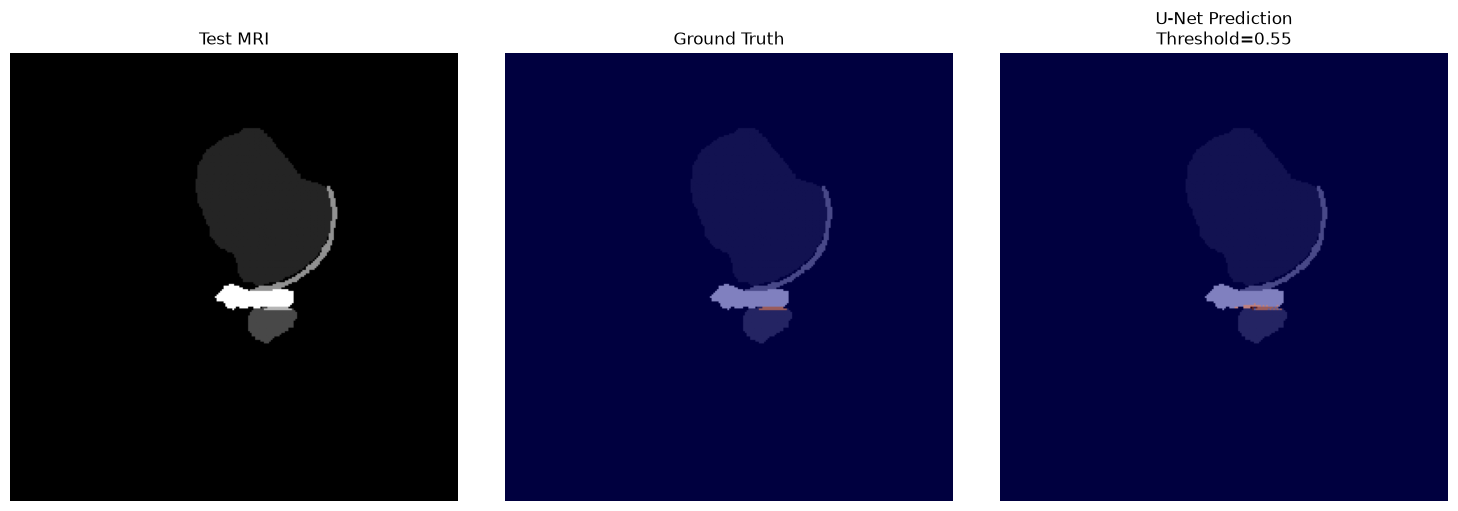

Best threshold: 0.55
Predicted foreground pixels: 45
Dice: 0.5753424656746107


In [75]:
best_threshold = 0.55

prediction = (
    probability[0, 0].cpu().numpy() > best_threshold
).astype(np.uint8)

plt.figure(figsize=(15, 5))

# 1. Original MRI
plt.subplot(1, 3, 1)
plt.imshow(test_img_np, cmap="gray")
plt.title("Test MRI")
plt.axis("off")

# 2. Ground truth
plt.subplot(1, 3, 2)
plt.imshow(test_img_np, cmap="gray")
plt.imshow(test_mask_np, cmap="jet", alpha=0.5)
plt.title("Ground Truth")
plt.axis("off")

# 3. Prediction
plt.subplot(1, 3, 3)
plt.imshow(test_img_np, cmap="gray")
plt.imshow(prediction, cmap="jet", alpha=0.5)
plt.title(f"U-Net Prediction\nThreshold={best_threshold}")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Best threshold:", best_threshold)
print("Predicted foreground pixels:", prediction.sum())
print("Dice:", best_dice)

In [76]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

def predict_knee_mri(image_path, threshold=0.55):

    # -----------------------------
    # 1. Check file
    # -----------------------------
    if not os.path.exists(image_path):
        print("ERROR: File not found")
        print(image_path)
        return

    # -----------------------------
    # 2. Load image
    # -----------------------------
    img = Image.open(image_path).convert("L")

    print("Image loaded successfully!")
    print("Original size:", img.size)

    # -----------------------------
    # 3. Resize to model input
    # -----------------------------
    img_resized = img.resize((256, 256))

    # -----------------------------
    # 4. Convert to numpy
    # -----------------------------
    img_np = np.array(img_resized).astype(np.float32) / 255.0

    # -----------------------------
    # 5. Create tensor
    # -----------------------------
    image_tensor = torch.from_numpy(img_np)
    image_tensor = image_tensor.unsqueeze(0).unsqueeze(0)

    image_tensor = image_tensor.to(device)

    # -----------------------------
    # 6. Model prediction
    # -----------------------------
    model.eval()

    with torch.no_grad():
        output = model(image_tensor)
        probability = torch.sigmoid(output)

    probability_np = probability[0, 0].cpu().numpy()

    # -----------------------------
    # 7. Create segmentation
    # -----------------------------
    prediction = (
        probability_np > threshold
    ).astype(np.uint8)

    # -----------------------------
    # 8. Statistics
    # -----------------------------
    foreground_pixels = prediction.sum()
    foreground_percentage = (
        foreground_pixels / (256 * 256)
    ) * 100

    print()
    print("MODEL RESULT")
    print("============")
    print("Probability min:", probability_np.min())
    print("Probability max:", probability_np.max())
    print("Probability mean:", probability_np.mean())
    print("Threshold:", threshold)
    print("Foreground pixels:", foreground_pixels)
    print("Foreground percentage:", foreground_percentage)

    # -----------------------------
    # 9. Display result
    # -----------------------------
    plt.figure(figsize=(15, 5))

    # Original
    plt.subplot(1, 3, 1)
    plt.imshow(img_resized, cmap="gray")
    plt.title("Input Knee MRI")
    plt.axis("off")

    # Probability
    plt.subplot(1, 3, 2)
    plt.imshow(probability_np, cmap="hot")
    plt.colorbar()
    plt.title("Prediction Probability")
    plt.axis("off")

    # Segmentation
    plt.subplot(1, 3, 3)
    plt.imshow(img_resized, cmap="gray")
    plt.imshow(
        prediction,
        cmap="jet",
        alpha=0.5
    )
    plt.title(
        f"Predicted Segmentation\n"
        f"Threshold = {threshold}"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    return prediction, probability_np

Image loaded successfully!
Original size: (516, 387)

MODEL RESULT
Probability min: 0.049356792
Probability max: 0.57127756
Probability mean: 0.12907109
Threshold: 0.55
Foreground pixels: 2
Foreground percentage: 0.0030517578125


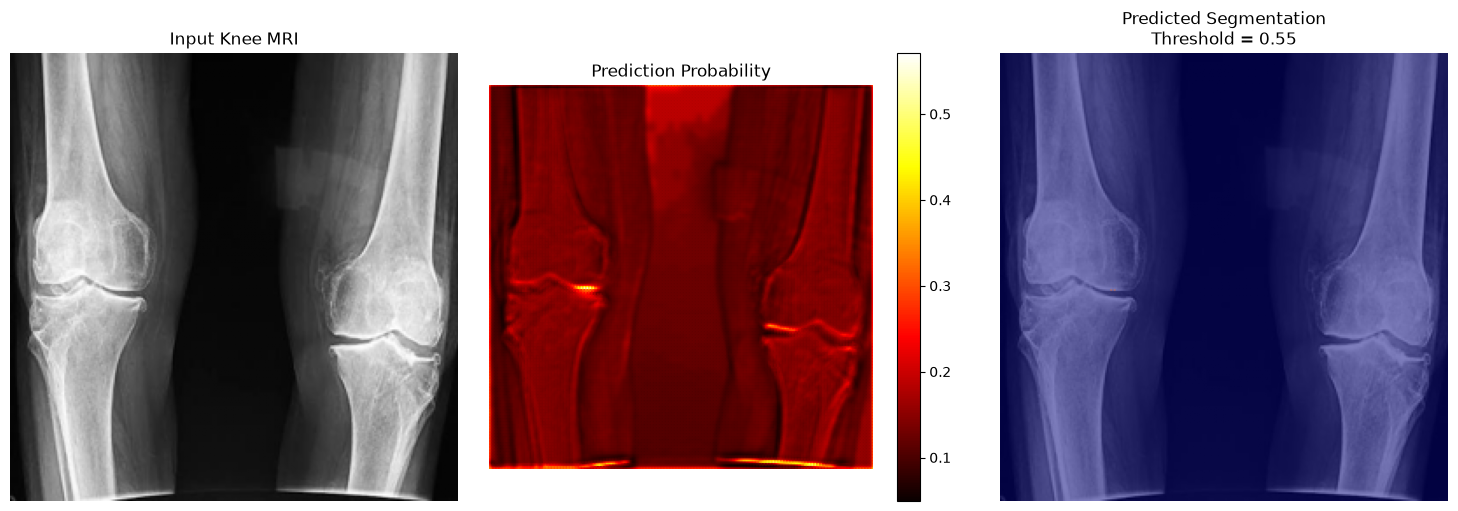

In [77]:
image_path = r"C:\Users\asus\Downloads\test-img.jpeg"

prediction, probability = predict_knee_mri(
    image_path,
    threshold=0.55
)

In [78]:
image_path = r"C:\Users\asus\Downloads\another_knee_mri.jpeg"

prediction, probability = predict_knee_mri(
    image_path,
    threshold=0.55
)

ERROR: File not found
C:\Users\asus\Downloads\another_knee_mri.jpeg


TypeError: cannot unpack non-iterable NoneType object

In [79]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tkinter as tk
from tkinter import filedialog

print("Ready to select an MRI image.")

Ready to select an MRI image.


In [ ]:
root = tk.Tk()
root.withdraw()

image_path = filedialog.askopenfilename(
    title="Select a Knee MRI Image",
    filetypes=[
        ("Image files", "*.png *.jpg *.jpeg *.bmp *.tif *.tiff"),
        ("All files", "*.*")
    ]
)

root.destroy()

print("Selected image:")
print(image_path)

In [ ]:
root = tk.Tk()
root.withdraw()

image_path = filedialog.askopenfilename(
    title="Select a Knee MRI Image",
    filetypes=[
        ("Image files", "*.png *.jpg *.jpeg *.bmp *.tif *.tiff"),
        ("All files", "*.*")
    ]
)

root.destroy()

print("Selected image:")
print(image_path)

In [ ]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

# PUT YOUR IMAGE PATH HERE
image_path = r"C:\Users\asus\Downloads\TM.png"

# Load image
img = Image.open(image_path).convert("L")

print("Image loaded successfully!")
print("Original size:", img.size)

# Resize exactly like training
img_resized = img.resize((256, 256))

# Normalize
img_np = np.array(img_resized).astype(np.float32) / 255.0

# Tensor
input_tensor = torch.tensor(img_np, dtype=torch.float32)
input_tensor = input_tensor.unsqueeze(0).unsqueeze(0)

# Model prediction
model.eval()

with torch.no_grad():
    output = model(input_tensor.to(device))
    probability = torch.sigmoid(output)

probability = probability.cpu().numpy()[0, 0]

# Use your best threshold
threshold = 0.55
prediction = (probability > threshold).astype(np.uint8)

print("Probability min:", probability.min())
print("Probability max:", probability.max())
print("Probability mean:", probability.mean())
print("Predicted foreground pixels:", prediction.sum())

# Display
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_resized, cmap="gray")
plt.title("Input MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_resized, cmap="gray")
plt.imshow(prediction, cmap="jet", alpha=0.5)
plt.title("U-Net Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image

image_path = r"C:\Users\asus\Downloads\test-img.jpeg"

img = Image.open(image_path).convert("L")

print("Image loaded successfully!")
print("Image size:", img.size)

In [1]:
print("HELLO")

HELLO


In [2]:
from PIL import Image

image_path = r"C:\Users\asus\Downloads\test-img.jpeg"

img = Image.open(image_path).convert("L")

print("Image loaded successfully!")
print("Image size:", img.size)

Image loaded successfully!
Image size: (516, 387)


In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Resize exactly like training
img_resized = img.resize((256, 256))

# Convert to NumPy and normalize
img_np = np.array(img_resized).astype(np.float32) / 255.0

# Convert to PyTorch tensor
# Shape: [batch, channel, height, width]
input_tensor = torch.tensor(img_np, dtype=torch.float32)
input_tensor = input_tensor.unsqueeze(0).unsqueeze(0)

print("Input tensor shape:", input_tensor.shape)

# Run U-Net
model.eval()

with torch.no_grad():
    output = model(input_tensor)
    probability = torch.sigmoid(output)[0, 0].cpu().numpy()

print("Prediction completed!")
print("Probability min:", probability.min())
print("Probability max:", probability.max())
print("Probability mean:", probability.mean())

# Your selected threshold
threshold = 0.55
prediction = (probability > threshold).astype(np.uint8)

print("Threshold:", threshold)
print("Predicted foreground pixels:", prediction.sum())

Input tensor shape: torch.Size([1, 1, 256, 256])


NameError: name 'model' is not defined

In [4]:
import os

for root, dirs, files in os.walk(r"C:\Users\asus\Desktop\meddd"):
    for file in files:
        if file.endswith((".pth", ".pt")):
            print(os.path.join(root, file))

C:\Users\asus\Desktop\meddd\data\oai_unet_model.pth


In [5]:
class UNet(...):

_IncompleteInputError: incomplete input (4084151827.py, line 1)

In [6]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(1, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)


print("U-Net class created successfully.")

U-Net class created successfully.


In [7]:
model = UNet()

print("Model created successfully!")

Model created successfully!


In [8]:
model_path = r"C:\Users\asus\Desktop\meddd\data\oai_unet_model.pth"

checkpoint = torch.load(
    model_path,
    map_location="cpu"
)

print("Checkpoint loaded!")
print(type(checkpoint))

Checkpoint loaded!
<class 'collections.OrderedDict'>


In [9]:
model.load_state_dict(checkpoint)
print("Weights loaded successfully!")

Weights loaded successfully!


Image loaded successfully!
Original image size: (911, 423)
Input tensor shape: torch.Size([1, 1, 256, 256])
Probability min: 0.0366688
Probability max: 0.42795703
Probability mean: 0.1628948
Threshold: 0.55
Predicted foreground pixels: 0


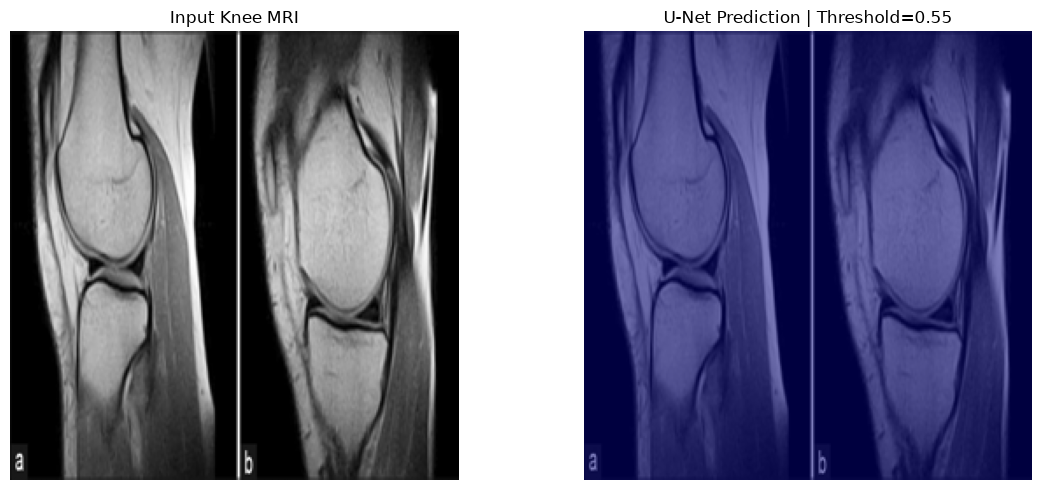

In [10]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

# ============================================================
# 1. PUT YOUR IMAGE PATH HERE
# ============================================================

image_path = r"C:\Users\asus\Downloads\TM.png"

# ============================================================
# 2. LOAD IMAGE
# ============================================================

img = Image.open(image_path).convert("L")

print("Image loaded successfully!")
print("Original image size:", img.size)

# ============================================================
# 3. RESIZE EXACTLY LIKE TRAINING
# ============================================================

img_resized = img.resize((256, 256))

# ============================================================
# 4. CONVERT TO NUMPY + NORMALIZE
# ============================================================

img_np = np.array(img_resized).astype(np.float32) / 255.0

# ============================================================
# 5. CREATE TENSOR
# ============================================================

input_tensor = torch.tensor(
    img_np,
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0)

print("Input tensor shape:", input_tensor.shape)

# ============================================================
# 6. MOVE MODEL TO CPU
# ============================================================

device = torch.device("cpu")
model = model.to(device)
input_tensor = input_tensor.to(device)

# ============================================================
# 7. PREDICTION
# ============================================================

model.eval()

with torch.no_grad():
    output = model(input_tensor)

    probability = torch.sigmoid(output)[0, 0].cpu().numpy()

# ============================================================
# 8. THRESHOLD
# ============================================================

threshold = 0.55

prediction = (probability > threshold).astype(np.uint8)

print("Probability min:", probability.min())
print("Probability max:", probability.max())
print("Probability mean:", probability.mean())
print("Threshold:", threshold)
print("Predicted foreground pixels:", prediction.sum())

# ============================================================
# 9. DISPLAY RESULT
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_resized, cmap="gray")
plt.title("Input Knee MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_resized, cmap="gray")
plt.imshow(prediction, cmap="jet", alpha=0.5)
plt.title(f"U-Net Prediction | Threshold={threshold}")
plt.axis("off")

plt.tight_layout()
plt.show()

Probability min : 0.0366688
Probability max : 0.42795703
Probability mean: 0.1628948

THRESHOLD TEST
Threshold 0.10 | Foreground pixels: 57415
Threshold 0.15 | Foreground pixels: 19125
Threshold 0.20 | Foreground pixels: 13792
Threshold 0.25 | Foreground pixels: 12607
Threshold 0.30 | Foreground pixels: 8086
Threshold 0.35 | Foreground pixels: 2584
Threshold 0.40 | Foreground pixels: 645
Threshold 0.45 | Foreground pixels: 0
Threshold 0.50 | Foreground pixels: 0
Threshold 0.55 | Foreground pixels: 0


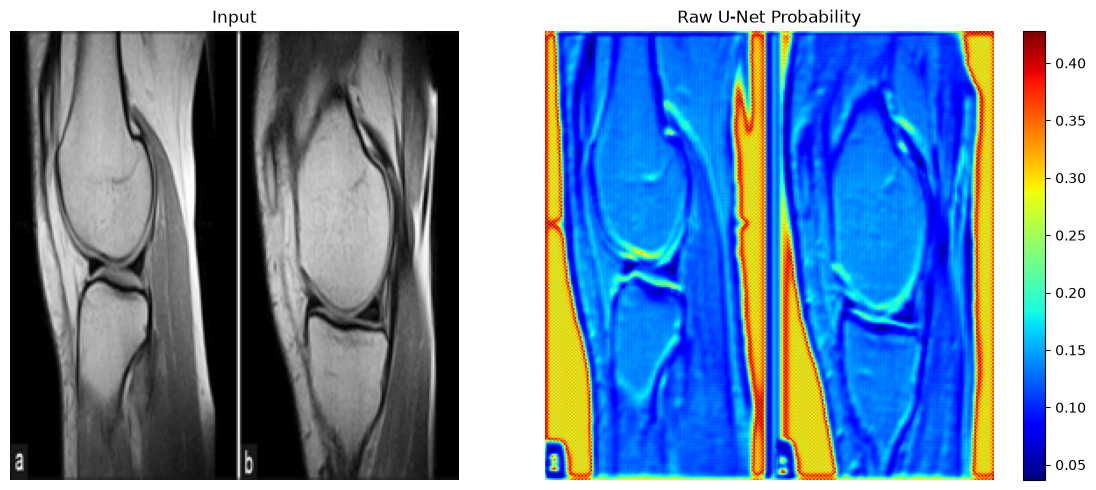

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torch

print("Probability min :", probability.min())
print("Probability max :", probability.max())
print("Probability mean:", probability.mean())

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55]

print("\nTHRESHOLD TEST")
print("=" * 40)

for t in thresholds:
    mask = (probability > t).astype(np.uint8)
    print(f"Threshold {t:.2f} | Foreground pixels: {mask.sum()}")

# Show probability itself
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_resized, cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(probability, cmap="jet")
plt.colorbar()
plt.title("Raw U-Net Probability")
plt.axis("off")

plt.tight_layout()
plt.show()

Original size: (516, 387)

LEFT MRI
Min : 0.054767054
Max : 0.60836846
Mean: 0.13157141

RIGHT MRI
Min : 0.048459787
Max : 0.5044673
Mean: 0.13067439

LEFT THRESHOLDS
Threshold 0.20 | Pixels 1770
Threshold 0.25 | Pixels 939
Threshold 0.30 | Pixels 267
Threshold 0.35 | Pixels 81
Threshold 0.40 | Pixels 46
Threshold 0.45 | Pixels 23
Threshold 0.50 | Pixels 11
Threshold 0.55 | Pixels 7

RIGHT THRESHOLDS
Threshold 0.20 | Pixels 1605
Threshold 0.25 | Pixels 1021
Threshold 0.30 | Pixels 294
Threshold 0.35 | Pixels 177
Threshold 0.40 | Pixels 81
Threshold 0.45 | Pixels 23
Threshold 0.50 | Pixels 2
Threshold 0.55 | Pixels 0


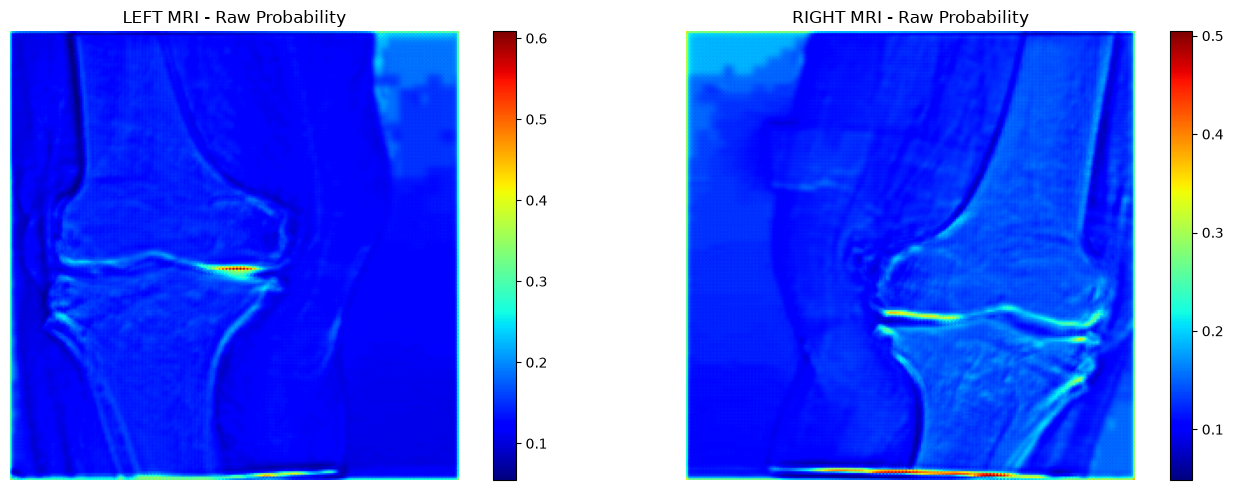

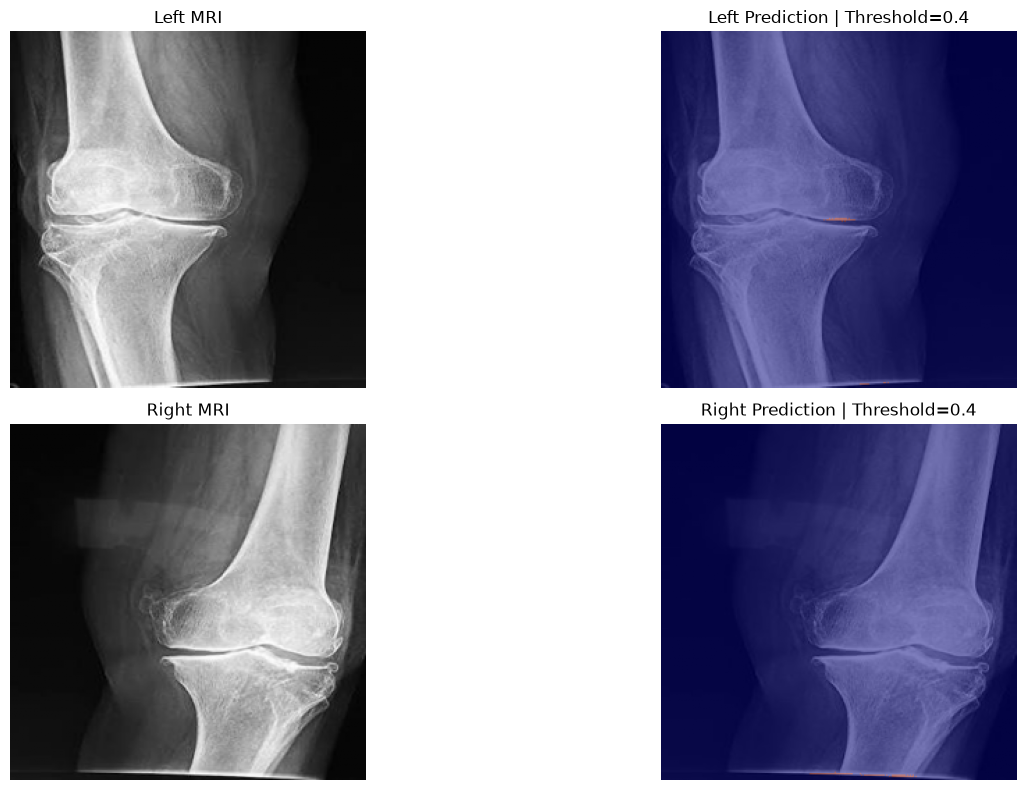

In [13]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

# ============================================================
# IMAGE YOU WANT TO TEST
# ============================================================

image_path = r"C:\Users\asus\Downloads\test-img.jpeg"

# ============================================================
# LOAD ORIGINAL IMAGE
# ============================================================

original = Image.open(image_path).convert("L")

print("Original size:", original.size)

img_np = np.array(original)

# ============================================================
# SPLIT INTO LEFT AND RIGHT MRI
# ============================================================

h, w = img_np.shape

middle = w // 2

left_img = img_np[:, :middle]
right_img = img_np[:, middle:]

# ============================================================
# REMOVE VERY SMALL EMPTY BORDERS
# ============================================================

def crop_nonzero(img, threshold=8):

    mask = img > threshold

    coords = np.argwhere(mask)

    if coords.size == 0:
        return img

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    return img[y_min:y_max+1, x_min:x_max+1]


left_img = crop_nonzero(left_img)
right_img = crop_nonzero(right_img)

# ============================================================
# FUNCTION FOR ONE MRI SLICE
# ============================================================

def predict_slice(slice_np):

    # Convert to PIL
    slice_pil = Image.fromarray(slice_np)

    # Resize exactly like training
    slice_resized = slice_pil.resize((256, 256))

    # Normalize
    img = np.array(slice_resized).astype(np.float32) / 255.0

    # Tensor
    tensor = torch.tensor(
        img,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)

    tensor = tensor.to(device)

    # Prediction
    model.eval()

    with torch.no_grad():
        output = model(tensor)
        probability = torch.sigmoid(output)[0, 0].cpu().numpy()

    return slice_resized, probability


# ============================================================
# PREDICT BOTH SLICES
# ============================================================

left_resized, left_probability = predict_slice(left_img)

right_resized, right_probability = predict_slice(right_img)


# ============================================================
# PRINT PROBABILITY INFORMATION
# ============================================================

print("\nLEFT MRI")
print("Min :", left_probability.min())
print("Max :", left_probability.max())
print("Mean:", left_probability.mean())

print("\nRIGHT MRI")
print("Min :", right_probability.min())
print("Max :", right_probability.max())
print("Mean:", right_probability.mean())


# ============================================================
# TEST THRESHOLDS
# ============================================================

thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55]

print("\nLEFT THRESHOLDS")
print("=" * 40)

for t in thresholds:
    mask = (left_probability > t).astype(np.uint8)
    print(
        f"Threshold {t:.2f} | "
        f"Pixels {mask.sum()}"
    )


print("\nRIGHT THRESHOLDS")
print("=" * 40)

for t in thresholds:
    mask = (right_probability > t).astype(np.uint8)
    print(
        f"Threshold {t:.2f} | "
        f"Pixels {mask.sum()}"
    )


# ============================================================
# DISPLAY RAW PROBABILITY
# ============================================================

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(left_probability, cmap="jet")
plt.colorbar()
plt.title("LEFT MRI - Raw Probability")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(right_probability, cmap="jet")
plt.colorbar()
plt.title("RIGHT MRI - Raw Probability")
plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# DISPLAY SEGMENTATION
# ============================================================

threshold = 0.40

left_prediction = (
    left_probability > threshold
).astype(np.uint8)

right_prediction = (
    right_probability > threshold
).astype(np.uint8)


plt.figure(figsize=(16, 8))

# Left input
plt.subplot(2, 2, 1)
plt.imshow(left_resized, cmap="gray")
plt.title("Left MRI")
plt.axis("off")

# Left prediction
plt.subplot(2, 2, 2)
plt.imshow(left_resized, cmap="gray")
plt.imshow(
    left_prediction,
    cmap="jet",
    alpha=0.5
)
plt.title(
    f"Left Prediction | Threshold={threshold}"
)
plt.axis("off")

# Right input
plt.subplot(2, 2, 3)
plt.imshow(right_resized, cmap="gray")
plt.title("Right MRI")
plt.axis("off")

# Right prediction
plt.subplot(2, 2, 4)
plt.imshow(right_resized, cmap="gray")
plt.imshow(
    right_prediction,
    cmap="jet",
    alpha=0.5
)
plt.title(
    f"Right Prediction | Threshold={threshold}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

Image found!
Path: C:\Users\asus\Downloads\google-knee-mri.jpg
Original image size: (2560, 1439)
Input tensor: torch.Size([1, 1, 256, 256])
Device: cpu

PROBABILITY
Minimum : 0.038019392639398575
Maximum : 0.42678093910217285
Mean    : 0.1802457571029663

THRESHOLD TEST
Threshold 0.30 | Foreground pixels: 11358
Threshold 0.35 | Foreground pixels: 2351
Threshold 0.40 | Foreground pixels: 446
Threshold 0.45 | Foreground pixels: 0
Threshold 0.50 | Foreground pixels: 0
Threshold 0.55 | Foreground pixels: 0

FINAL VISUALIZATION
Threshold: 0.4
Foreground pixels: 446


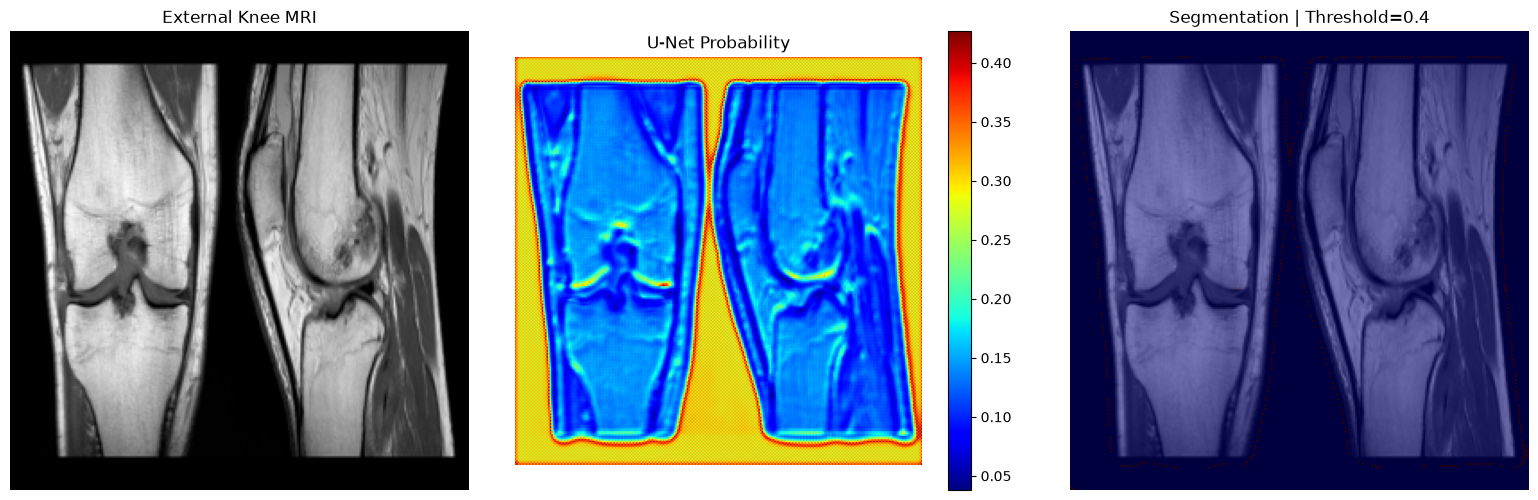

In [14]:
# ============================================================
# EXTERNAL KNEE MRI TESTING
# Google / Website MRI image
# ============================================================

from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# 1. PUT YOUR DOWNLOADED MRI IMAGE PATH HERE
# ------------------------------------------------------------

image_path = r"C:\Users\asus\Downloads\google-knee-mri.jpg"

# ------------------------------------------------------------
# 2. CHECK FILE
# ------------------------------------------------------------

if not os.path.exists(image_path):
    print("ERROR: File not found!")
    print(image_path)

else:
    print("Image found!")
    print("Path:", image_path)

    # --------------------------------------------------------
    # 3. LOAD IMAGE
    # --------------------------------------------------------

    img = Image.open(image_path).convert("L")

    print("Original image size:", img.size)

    # --------------------------------------------------------
    # 4. RESIZE EXACTLY LIKE TRAINING
    # --------------------------------------------------------

    img_resized = img.resize((256, 256))

    # --------------------------------------------------------
    # 5. NORMALIZE
    # --------------------------------------------------------

    img_np = np.array(img_resized).astype(np.float32) / 255.0

    # --------------------------------------------------------
    # 6. CREATE TENSOR
    # --------------------------------------------------------

    input_tensor = torch.tensor(
        img_np,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)

    # Use same device as model
    device = next(model.parameters()).device
    input_tensor = input_tensor.to(device)

    print("Input tensor:", input_tensor.shape)
    print("Device:", device)

    # --------------------------------------------------------
    # 7. RUN U-NET
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():
        output = model(input_tensor)

        probability = torch.sigmoid(output)[0, 0].cpu().numpy()

    # --------------------------------------------------------
    # 8. PROBABILITY INFORMATION
    # --------------------------------------------------------

    print("\nPROBABILITY")
    print("==============================")
    print("Minimum :", float(probability.min()))
    print("Maximum :", float(probability.max()))
    print("Mean    :", float(probability.mean()))

    # --------------------------------------------------------
    # 9. TEST THRESHOLDS
    # --------------------------------------------------------

    print("\nTHRESHOLD TEST")
    print("==============================")

    thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55]

    for t in thresholds:

        mask = (probability > t).astype(np.uint8)

        print(
            f"Threshold {t:.2f} | "
            f"Foreground pixels: {int(mask.sum())}"
        )

    # --------------------------------------------------------
    # 10. USE 0.40 FOR INITIAL EXTERNAL-MRI VISUALIZATION
    # --------------------------------------------------------

    threshold = 0.40

    prediction = (
        probability > threshold
    ).astype(np.uint8)

    print("\nFINAL VISUALIZATION")
    print("==============================")
    print("Threshold:", threshold)
    print("Foreground pixels:", int(prediction.sum()))

    # --------------------------------------------------------
    # 11. DISPLAY
    # --------------------------------------------------------

    plt.figure(figsize=(16, 5))

    # Original MRI
    plt.subplot(1, 3, 1)
    plt.imshow(img_resized, cmap="gray")
    plt.title("External Knee MRI")
    plt.axis("off")

    # Raw probability
    plt.subplot(1, 3, 2)
    plt.imshow(probability, cmap="jet")
    plt.colorbar()
    plt.title("U-Net Probability")
    plt.axis("off")

    # Segmentation overlay
    plt.subplot(1, 3, 3)
    plt.imshow(img_resized, cmap="gray")
    plt.imshow(
        prediction,
        cmap="jet",
        alpha=0.5
    )
    plt.title(
        f"Segmentation | Threshold={threshold}"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Image found!
Path: C:\Users\asus\Downloads\website-mri.jpeg
Original image size: (554, 554)
Input tensor: torch.Size([1, 1, 256, 256])
Device: cpu

PROBABILITY
Minimum : 0.03994502127170563
Maximum : 0.4286288917064667
Mean    : 0.1876087784767151

THRESHOLD TEST
Threshold 0.30 | Foreground pixels: 12966
Threshold 0.35 | Foreground pixels: 1757
Threshold 0.40 | Foreground pixels: 293
Threshold 0.45 | Foreground pixels: 0
Threshold 0.50 | Foreground pixels: 0
Threshold 0.55 | Foreground pixels: 0

FINAL VISUALIZATION
Threshold: 0.4
Foreground pixels: 293


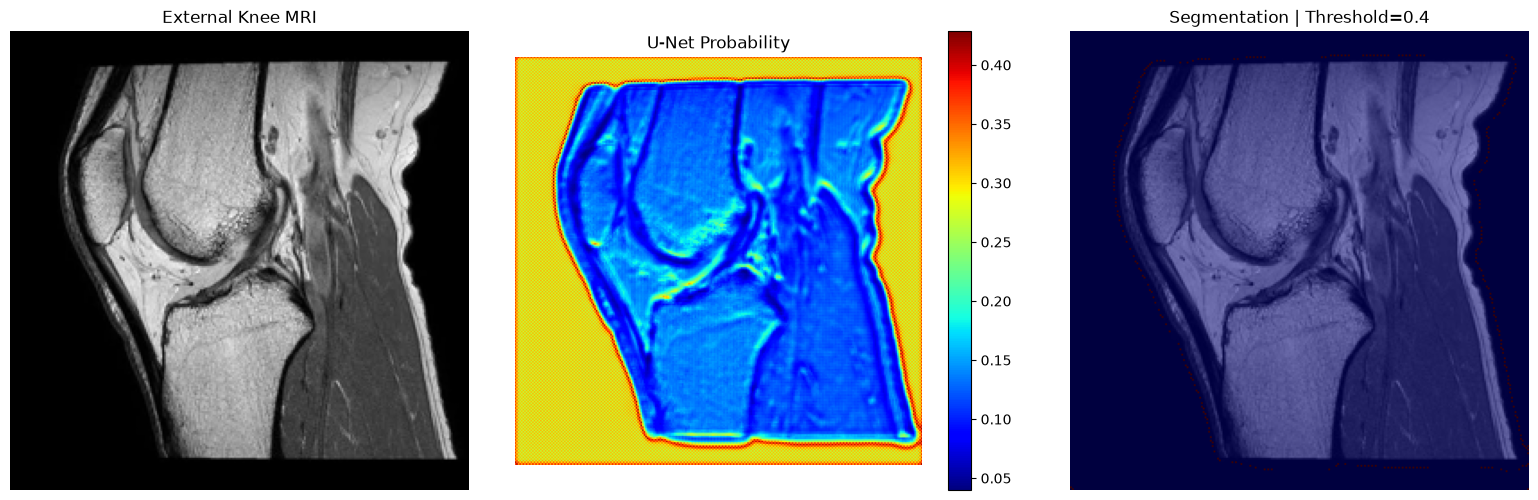

In [15]:
# ============================================================
# EXTERNAL KNEE MRI TESTING
# Google / Website MRI image
# ============================================================

from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# 1. PUT YOUR DOWNLOADED MRI IMAGE PATH HERE
# ------------------------------------------------------------

image_path = r"C:\Users\asus\Downloads\website-mri.jpeg"

# ------------------------------------------------------------
# 2. CHECK FILE
# ------------------------------------------------------------

if not os.path.exists(image_path):
    print("ERROR: File not found!")
    print(image_path)

else:
    print("Image found!")
    print("Path:", image_path)

    # --------------------------------------------------------
    # 3. LOAD IMAGE
    # --------------------------------------------------------

    img = Image.open(image_path).convert("L")

    print("Original image size:", img.size)

    # --------------------------------------------------------
    # 4. RESIZE EXACTLY LIKE TRAINING
    # --------------------------------------------------------

    img_resized = img.resize((256, 256))

    # --------------------------------------------------------
    # 5. NORMALIZE
    # --------------------------------------------------------

    img_np = np.array(img_resized).astype(np.float32) / 255.0

    # --------------------------------------------------------
    # 6. CREATE TENSOR
    # --------------------------------------------------------

    input_tensor = torch.tensor(
        img_np,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)

    # Use same device as model
    device = next(model.parameters()).device
    input_tensor = input_tensor.to(device)

    print("Input tensor:", input_tensor.shape)
    print("Device:", device)

    # --------------------------------------------------------
    # 7. RUN U-NET
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():
        output = model(input_tensor)

        probability = torch.sigmoid(output)[0, 0].cpu().numpy()

    # --------------------------------------------------------
    # 8. PROBABILITY INFORMATION
    # --------------------------------------------------------

    print("\nPROBABILITY")
    print("==============================")
    print("Minimum :", float(probability.min()))
    print("Maximum :", float(probability.max()))
    print("Mean    :", float(probability.mean()))

    # --------------------------------------------------------
    # 9. TEST THRESHOLDS
    # --------------------------------------------------------

    print("\nTHRESHOLD TEST")
    print("==============================")

    thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55]

    for t in thresholds:

        mask = (probability > t).astype(np.uint8)

        print(
            f"Threshold {t:.2f} | "
            f"Foreground pixels: {int(mask.sum())}"
        )

    # --------------------------------------------------------
    # 10. USE 0.40 FOR INITIAL EXTERNAL-MRI VISUALIZATION
    # --------------------------------------------------------

    threshold = 0.40

    prediction = (
        probability > threshold
    ).astype(np.uint8)

    print("\nFINAL VISUALIZATION")
    print("==============================")
    print("Threshold:", threshold)
    print("Foreground pixels:", int(prediction.sum()))

    # --------------------------------------------------------
    # 11. DISPLAY
    # --------------------------------------------------------

    plt.figure(figsize=(16, 5))

    # Original MRI
    plt.subplot(1, 3, 1)
    plt.imshow(img_resized, cmap="gray")
    plt.title("External Knee MRI")
    plt.axis("off")

    # Raw probability
    plt.subplot(1, 3, 2)
    plt.imshow(probability, cmap="jet")
    plt.colorbar()
    plt.title("U-Net Probability")
    plt.axis("off")

    # Segmentation overlay
    plt.subplot(1, 3, 3)
    plt.imshow(img_resized, cmap="gray")
    plt.imshow(
        prediction,
        cmap="jet",
        alpha=0.5
    )
    plt.title(
        f"Segmentation | Threshold={threshold}"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Checking image...
Image found!
Path: C:\Users\asus\Desktop\meddd\data\oai_samples\9002411_RIGHT_V00_slice018_img.png
Original image size: (256, 256)
Input tensor: torch.Size([1, 1, 256, 256])
Device: cpu

PROBABILITY
Minimum: 0.051770214
Maximum: 0.72106206
Mean   : 0.27904785

SEGMENTATION
Threshold: 0.4
Foreground pixels: 243


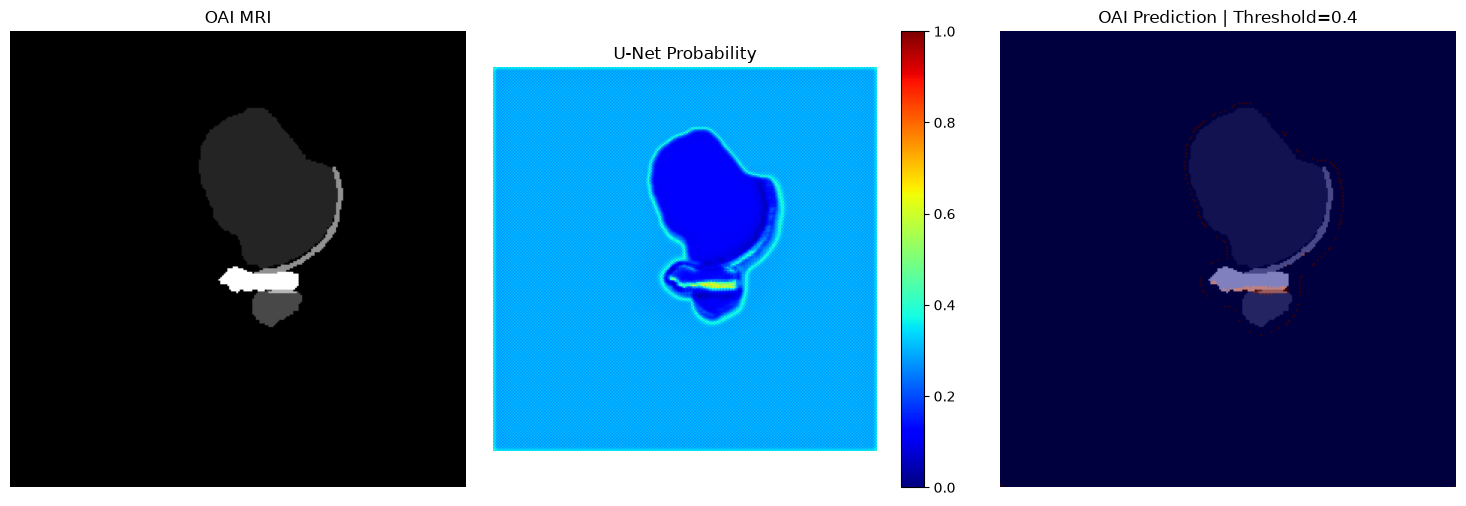

In [16]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

# ============================================================
# TEST OAI MRI
# ============================================================

image_path = r"C:\Users\asus\Desktop\meddd\data\oai_samples\9002411_RIGHT_V00_slice018_img.png"
threshold = 0.40

# ------------------------------------------------------------
# Check file
# ------------------------------------------------------------

print("Checking image...")

if not os.path.exists(image_path):
    print("ERROR: File not found!")
    print(image_path)

else:

    print("Image found!")
    print("Path:", image_path)

    # --------------------------------------------------------
    # Load image
    # --------------------------------------------------------

    img = Image.open(image_path).convert("L")

    print("Original image size:", img.size)

    # --------------------------------------------------------
    # Resize exactly like training
    # --------------------------------------------------------

    img_resized = img.resize((256, 256))

    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    img_np = np.array(img_resized).astype(
        np.float32
    ) / 255.0

    # --------------------------------------------------------
    # Tensor
    # --------------------------------------------------------

    input_tensor = torch.tensor(
        img_np,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)

    # Put tensor on same device as model
    device = next(model.parameters()).device
    input_tensor = input_tensor.to(device)

    print("Input tensor:", input_tensor.shape)
    print("Device:", device)

    # --------------------------------------------------------
    # U-Net prediction
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():

        output = model(input_tensor)

        probability = torch.sigmoid(output)[0, 0].cpu().numpy()

    # --------------------------------------------------------
    # Probability information
    # --------------------------------------------------------

    print()
    print("PROBABILITY")
    print("==============================")

    print("Minimum:", probability.min())
    print("Maximum:", probability.max())
    print("Mean   :", probability.mean())

    # --------------------------------------------------------
    # Threshold
    # --------------------------------------------------------

    prediction = (
        probability > threshold
    ).astype(np.uint8)

    print()
    print("SEGMENTATION")
    print("==============================")
    print("Threshold:", threshold)
    print("Foreground pixels:", prediction.sum())

    # --------------------------------------------------------
    # Display
    # --------------------------------------------------------

    plt.figure(figsize=(15, 5))

    # Original
    plt.subplot(1, 3, 1)

    plt.imshow(
        img_resized,
        cmap="gray"
    )

    plt.title("OAI MRI")
    plt.axis("off")

    # Probability
    plt.subplot(1, 3, 2)

    plt.imshow(
        probability,
        cmap="jet",
        vmin=0,
        vmax=1
    )

    plt.colorbar()

    plt.title("U-Net Probability")
    plt.axis("off")

    # Prediction
    plt.subplot(1, 3, 3)

    plt.imshow(
        img_resized,
        cmap="gray"
    )

    plt.imshow(
        prediction,
        cmap="jet",
        alpha=0.5
    )

    plt.title(
        f"OAI Prediction | Threshold={threshold}"
    )

    plt.axis("off")

    plt.tight_layout()
    plt.show()

Checking image...
Image found!
Original size: (554, 554)
Intensity low : 14.0
Intensity high: 191.0
Input tensor: torch.Size([1, 1, 256, 256])
Device: cpu

PROBABILITY
Minimum: 0.036897473
Maximum: 0.4690464
Mean   : 0.19340655

SEGMENTATION
Threshold: 0.4
Foreground pixels: 301


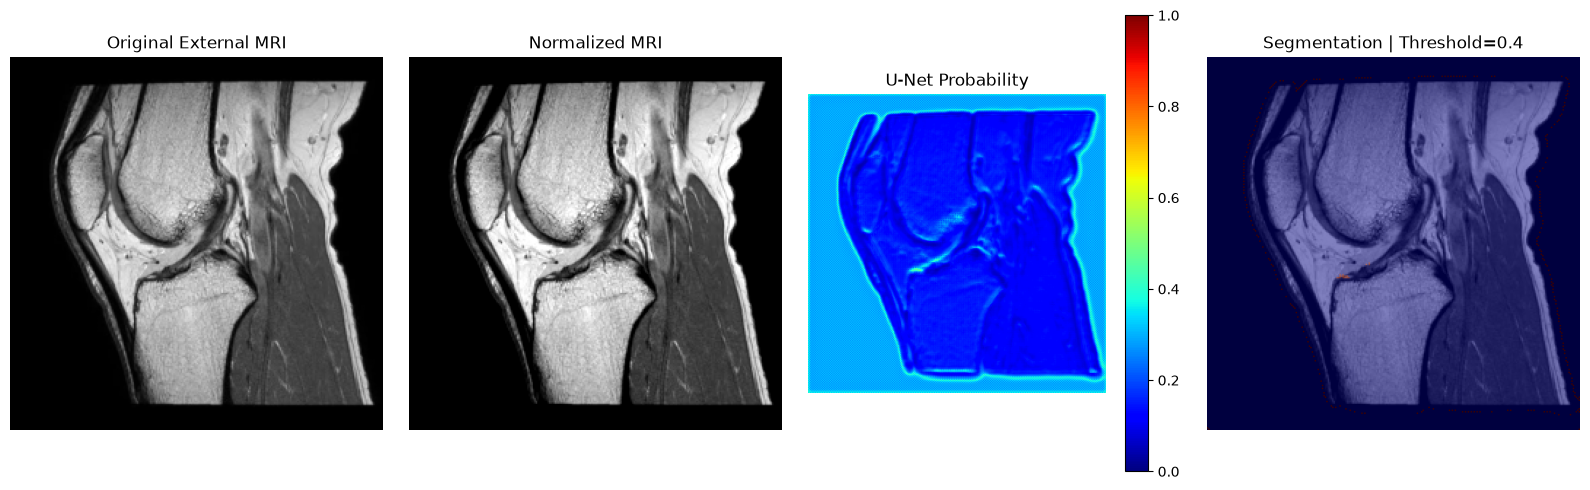

In [17]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

# ============================================================
# EXTERNAL MRI - IMPROVED INTENSITY NORMALIZATION
# ============================================================

image_path = r"C:\Users\asus\Downloads\website-mri.jpeg"

threshold = 0.40

print("Checking image...")

if not os.path.exists(image_path):

    print("ERROR: File not found!")
    print(image_path)

else:

    print("Image found!")

    # --------------------------------------------------------
    # Load
    # --------------------------------------------------------

    img = Image.open(image_path).convert("L")

    print("Original size:", img.size)

    img_np_original = np.array(img).astype(np.float32)

    # --------------------------------------------------------
    # Resize
    # --------------------------------------------------------

    img_resized = img.resize(
        (256, 256),
        Image.Resampling.BILINEAR
    )

    img_np = np.array(
        img_resized
    ).astype(np.float32)

    # --------------------------------------------------------
    # FIND MRI TISSUE / NON-BLACK REGION
    # --------------------------------------------------------

    # Ignore very dark background
    tissue_pixels = img_np[img_np > 10]

    if len(tissue_pixels) == 0:

        print("ERROR: Could not find MRI tissue.")

    else:

        # ----------------------------------------------------
        # Robust intensity normalization
        # ----------------------------------------------------

        low = np.percentile(
            tissue_pixels,
            1
        )

        high = np.percentile(
            tissue_pixels,
            99
        )

        print("Intensity low :", low)
        print("Intensity high:", high)

        # Normalize tissue intensity
        normalized = (
            img_np - low
        ) / (
            high - low + 1e-8
        )

        normalized = np.clip(
            normalized,
            0,
            1
        )

        # Keep black background black
        background = img_np <= 10
        normalized[background] = 0

        # ----------------------------------------------------
        # Tensor
        # ----------------------------------------------------

        input_tensor = torch.tensor(
            normalized,
            dtype=torch.float32
        ).unsqueeze(0).unsqueeze(0)

        device = next(
            model.parameters()
        ).device

        input_tensor = input_tensor.to(device)

        print(
            "Input tensor:",
            input_tensor.shape
        )

        print(
            "Device:",
            device
        )

        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        model.eval()

        with torch.no_grad():

            output = model(
                input_tensor
            )

            probability = torch.sigmoid(
                output
            )[0, 0].cpu().numpy()

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        prediction = (
            probability > threshold
        ).astype(np.uint8)

        print()
        print("PROBABILITY")
        print("==============================")

        print(
            "Minimum:",
            probability.min()
        )

        print(
            "Maximum:",
            probability.max()
        )

        print(
            "Mean   :",
            probability.mean()
        )

        print()
        print("SEGMENTATION")
        print("==============================")

        print(
            "Threshold:",
            threshold
        )

        print(
            "Foreground pixels:",
            prediction.sum()
        )

        # ----------------------------------------------------
        # DISPLAY
        # ----------------------------------------------------

        plt.figure(
            figsize=(16, 5)
        )

        # Original
        plt.subplot(1, 4, 1)

        plt.imshow(
            img_resized,
            cmap="gray"
        )

        plt.title(
            "Original External MRI"
        )

        plt.axis("off")

        # Normalized
        plt.subplot(1, 4, 2)

        plt.imshow(
            normalized,
            cmap="gray"
        )

        plt.title(
            "Normalized MRI"
        )

        plt.axis("off")

        # Probability
        plt.subplot(1, 4, 3)

        plt.imshow(
            probability,
            cmap="jet",
            vmin=0,
            vmax=1
        )

        plt.colorbar()

        plt.title(
            "U-Net Probability"
        )

        plt.axis("off")

        # Prediction
        plt.subplot(1, 4, 4)

        plt.imshow(
            normalized,
            cmap="gray"
        )

        plt.imshow(
            prediction,
            cmap="jet",
            alpha=0.5
        )

        plt.title(
            f"Segmentation | Threshold={threshold}"
        )

        plt.axis("off")

        plt.tight_layout()
        plt.show()

OAI intensity: 36.0 to 255.0
External intensity: 14.0 to 194.0
Input tensor: torch.Size([1, 1, 256, 256])
Device: cpu

PROBABILITY
Minimum: 0.041735407
Maximum: 0.430743
Mean   : 0.22305244

SEGMENTATION
Threshold: 0.4
Foreground pixels: 632


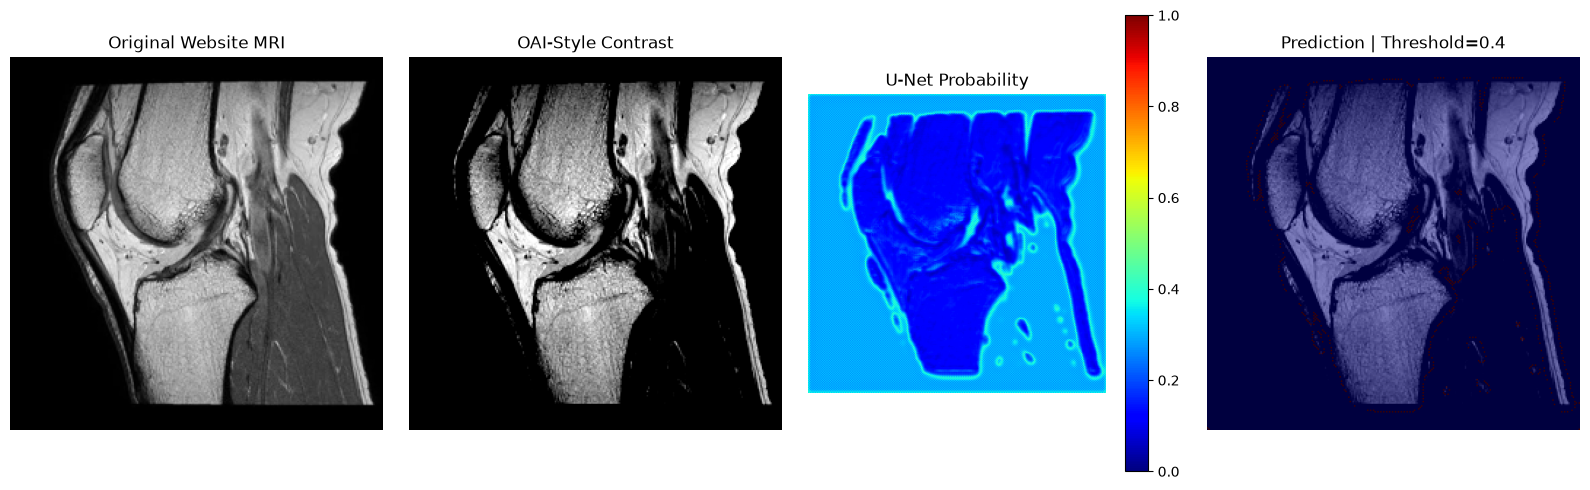

In [18]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

# ============================================================
# HISTOGRAM MATCHING TEST
# ============================================================

oai_path = r"C:\Users\asus\Desktop\meddd\data\oai_samples\9002411_RIGHT_V00_slice018_img.png"
external_path = r"C:\Users\asus\Downloads\website-mri.jpeg"

threshold = 0.40

# ------------------------------------------------------------
# Load images
# ------------------------------------------------------------

oai_img = Image.open(oai_path).convert("L")
external_img = Image.open(external_path).convert("L")

# Resize both
oai_img = oai_img.resize((256, 256))
external_img = external_img.resize((256, 256))

oai = np.array(oai_img).astype(np.float32)
external = np.array(external_img).astype(np.float32)

# ------------------------------------------------------------
# Simple percentile-based intensity matching
# ------------------------------------------------------------

oai_low = np.percentile(oai[oai > 10], 1)
oai_high = np.percentile(oai[oai > 10], 99)

ext_low = np.percentile(external[external > 10], 1)
ext_high = np.percentile(external[external > 10], 99)

print("OAI intensity:", oai_low, "to", oai_high)
print("External intensity:", ext_low, "to", ext_high)

# Normalize OAI
oai_norm = (oai - oai_low) / (oai_high - oai_low + 1e-8)
oai_norm = np.clip(oai_norm, 0, 1)

# Normalize external
ext_norm = (external - ext_low) / (ext_high - ext_low + 1e-8)
ext_norm = np.clip(ext_norm, 0, 1)

# ------------------------------------------------------------
# Match external contrast to OAI
# ------------------------------------------------------------

oai_mean = oai_norm[oai > 0].mean()
oai_std = oai_norm[oai > 0].std()

ext_mean = ext_norm[external > 0].mean()
ext_std = ext_norm[external > 0].std()

matched = (
    (ext_norm - ext_mean)
    / (ext_std + 1e-8)
) * oai_std + oai_mean

matched = np.clip(matched, 0, 1)

# Keep background black
matched[external <= 10] = 0

# ------------------------------------------------------------
# Tensor
# ------------------------------------------------------------

input_tensor = torch.tensor(
    matched,
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0)

device = next(model.parameters()).device
input_tensor = input_tensor.to(device)

print("Input tensor:", input_tensor.shape)
print("Device:", device)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

model.eval()

with torch.no_grad():
    output = model(input_tensor)
    probability = torch.sigmoid(output)[0, 0].cpu().numpy()

prediction = (
    probability > threshold
).astype(np.uint8)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print()
print("PROBABILITY")
print("==============================")
print("Minimum:", probability.min())
print("Maximum:", probability.max())
print("Mean   :", probability.mean())

print()
print("SEGMENTATION")
print("==============================")
print("Threshold:", threshold)
print("Foreground pixels:", prediction.sum())

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(external, cmap="gray")
plt.title("Original Website MRI")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(matched, cmap="gray")
plt.title("OAI-Style Contrast")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(probability, cmap="jet", vmin=0, vmax=1)
plt.colorbar()
plt.title("U-Net Probability")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(matched, cmap="gray")
plt.imshow(prediction, cmap="jet", alpha=0.5)
plt.title(f"Prediction | Threshold={threshold}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
import os
import glob
import numpy as np
from PIL import Image
import torch

# ============================================================
# OAI TEST SET EVALUATION
# ============================================================

oai_dir = r"C:\Users\asus\Desktop\meddd\data\oai_samples"

# Find all OAI image files
image_paths = sorted(
    glob.glob(os.path.join(oai_dir, "*_img.png"))
)

print("OAI images found:", len(image_paths))

# Check that corresponding masks exist
pairs = []

for img_path in image_paths:

    mask_path = img_path.replace("_img.png", "_mask.png")

    if os.path.exists(mask_path):
        pairs.append((img_path, mask_path))
    else:
        print("WARNING - mask missing:", os.path.basename(img_path))

print("Image-mask pairs:", len(pairs))

OAI images found: 60
Image-mask pairs: 60


In [20]:
# ============================================================
# CALCULATE DICE AND IoU
# ============================================================

THRESHOLD = 0.40

dice_scores = []
iou_scores = []

model.eval()

for img_path, mask_path in pairs:

    # -------------------------
    # Load image
    # -------------------------
    img = Image.open(img_path).convert("L")
    img = img.resize((256, 256))

    img_np = np.array(img).astype(np.float32) / 255.0

    input_tensor = torch.tensor(
        img_np,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)

    # -------------------------
    # Prediction
    # -------------------------
    with torch.no_grad():

        output = model(input_tensor)

        probability = torch.sigmoid(output)[0, 0].cpu().numpy()

    prediction = (probability > THRESHOLD).astype(np.uint8)

    # -------------------------
    # Load ground truth mask
    # -------------------------
    mask = Image.open(mask_path).convert("L")
    mask = mask.resize((256, 256))

    ground_truth = np.array(mask)

    # Convert mask to binary
    ground_truth = (ground_truth > 0).astype(np.uint8)

    # -------------------------
    # Dice
    # -------------------------
    intersection = np.logical_and(
        prediction,
        ground_truth
    ).sum()

    dice = (
        2.0 * intersection
        /
        (prediction.sum() + ground_truth.sum() + 1e-8)
    )

    # -------------------------
    # IoU
    # -------------------------
    union = np.logical_or(
        prediction,
        ground_truth
    ).sum()

    iou = (
        intersection
        /
        (union + 1e-8)
    )

    dice_scores.append(dice)
    iou_scores.append(iou)

    print(
        f"{os.path.basename(img_path):45s} "
        f"Dice={dice:.4f}  IoU={iou:.4f}"
    )


# ============================================================
# FINAL RESULTS
# ============================================================

print("\n" + "=" * 60)
print("FINAL OAI TEST RESULTS")
print("=" * 60)

print("Number of test images:", len(pairs))

print(f"Mean Dice : {np.mean(dice_scores):.4f}")
print(f"Mean IoU  : {np.mean(iou_scores):.4f}")

print(f"Median Dice : {np.median(dice_scores):.4f}")
print(f"Median IoU  : {np.median(iou_scores):.4f}")

print("=" * 60)

9000099_LEFT_V00_slice010_img.png             Dice=0.4144  IoU=0.2614
9000099_LEFT_V00_slice059_img.png             Dice=0.3467  IoU=0.2097
9000099_LEFT_V00_slice123_img.png             Dice=0.2344  IoU=0.1327
9000296_RIGHT_V00_slice014_img.png            Dice=0.0000  IoU=0.0000
9000296_RIGHT_V00_slice061_img.png            Dice=0.2632  IoU=0.1515
9000296_RIGHT_V00_slice134_img.png            Dice=0.2705  IoU=0.1564
9000622_LEFT_V00_slice013_img.png             Dice=0.1869  IoU=0.1031
9000622_LEFT_V00_slice053_img.png             Dice=0.2277  IoU=0.1285
9000622_LEFT_V00_slice115_img.png             Dice=0.4012  IoU=0.2510
9000622_RIGHT_V00_slice035_img.png            Dice=0.0118  IoU=0.0060
9000622_RIGHT_V00_slice097_img.png            Dice=0.3451  IoU=0.2085
9000622_RIGHT_V00_slice138_img.png            Dice=0.6087  IoU=0.4375
9000798_LEFT_V00_slice005_img.png             Dice=0.4798  IoU=0.3156
9000798_LEFT_V00_slice058_img.png             Dice=0.2779  IoU=0.1614
9000798_LEFT_V00_sli

In [21]:
print("\nINDIVIDUAL RESULTS")
print("=" * 60)

for (img_path, mask_path), dice, iou in zip(
    pairs,
    dice_scores,
    iou_scores
):
    print(
        f"{os.path.basename(img_path):45s}"
        f" Dice={dice:.4f}"
        f" IoU={iou:.4f}"
    )


INDIVIDUAL RESULTS
9000099_LEFT_V00_slice010_img.png             Dice=0.4144 IoU=0.2614
9000099_LEFT_V00_slice059_img.png             Dice=0.3467 IoU=0.2097
9000099_LEFT_V00_slice123_img.png             Dice=0.2344 IoU=0.1327
9000296_RIGHT_V00_slice014_img.png            Dice=0.0000 IoU=0.0000
9000296_RIGHT_V00_slice061_img.png            Dice=0.2632 IoU=0.1515
9000296_RIGHT_V00_slice134_img.png            Dice=0.2705 IoU=0.1564
9000622_LEFT_V00_slice013_img.png             Dice=0.1869 IoU=0.1031
9000622_LEFT_V00_slice053_img.png             Dice=0.2277 IoU=0.1285
9000622_LEFT_V00_slice115_img.png             Dice=0.4012 IoU=0.2510
9000622_RIGHT_V00_slice035_img.png            Dice=0.0118 IoU=0.0060
9000622_RIGHT_V00_slice097_img.png            Dice=0.3451 IoU=0.2085
9000622_RIGHT_V00_slice138_img.png            Dice=0.6087 IoU=0.4375
9000798_LEFT_V00_slice005_img.png             Dice=0.4798 IoU=0.3156
9000798_LEFT_V00_slice058_img.png             Dice=0.2779 IoU=0.1614
9000798_LEFT_V

In [22]:
# ============================================================
# THRESHOLD EVALUATION ON ALL 60 OAI TEST IMAGES
# ============================================================

thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55]

threshold_results = []

model.eval()

for threshold in thresholds:

    dice_scores_t = []
    iou_scores_t = []

    for img_path, mask_path in pairs:

        # Load image
        img = Image.open(img_path).convert("L")
        img = img.resize((256, 256))

        img_np = np.array(img).astype(np.float32) / 255.0

        input_tensor = torch.tensor(
            img_np,
            dtype=torch.float32
        ).unsqueeze(0).unsqueeze(0)

        # Prediction
        with torch.no_grad():
            output = model(input_tensor)
            probability = torch.sigmoid(
                output
            )[0, 0].cpu().numpy()

        prediction = (
            probability > threshold
        ).astype(np.uint8)

        # Ground truth
        mask = Image.open(mask_path).convert("L")
        mask = mask.resize((256, 256))

        ground_truth = (
            np.array(mask) > 0
        ).astype(np.uint8)

        # Dice
        intersection = np.logical_and(
            prediction,
            ground_truth
        ).sum()

        dice = (
            2 * intersection
            /
            (
                prediction.sum()
                + ground_truth.sum()
                + 1e-8
            )
        )

        # IoU
        union = np.logical_or(
            prediction,
            ground_truth
        ).sum()

        iou = intersection / (union + 1e-8)

        dice_scores_t.append(dice)
        iou_scores_t.append(iou)

    mean_dice = np.mean(dice_scores_t)
    mean_iou = np.mean(iou_scores_t)

    threshold_results.append(
        (threshold, mean_dice, mean_iou)
    )

    print(
        f"Threshold {threshold:.2f} | "
        f"Mean Dice = {mean_dice:.4f} | "
        f"Mean IoU = {mean_iou:.4f}"
    )


# Find best threshold by mean Dice
best = max(
    threshold_results,
    key=lambda x: x[1]
)

print("\n" + "=" * 60)
print("BEST DATASET THRESHOLD")
print("=" * 60)

print(f"Threshold : {best[0]:.2f}")
print(f"Mean Dice : {best[1]:.4f}")
print(f"Mean IoU  : {best[2]:.4f}")

Threshold 0.20 | Mean Dice = 0.0021 | Mean IoU = 0.0010
Threshold 0.25 | Mean Dice = 0.0020 | Mean IoU = 0.0010
Threshold 0.30 | Mean Dice = 0.0038 | Mean IoU = 0.0019
Threshold 0.35 | Mean Dice = 0.0602 | Mean IoU = 0.0314
Threshold 0.40 | Mean Dice = 0.2534 | Mean IoU = 0.1524
Threshold 0.45 | Mean Dice = 0.5145 | Mean IoU = 0.3844
Threshold 0.50 | Mean Dice = 0.5061 | Mean IoU = 0.3766
Threshold 0.55 | Mean Dice = 0.4332 | Mean IoU = 0.3140

BEST DATASET THRESHOLD
Threshold : 0.45
Mean Dice : 0.5145
Mean IoU  : 0.3844


FINAL U-NET EVALUATION
OAI directory : C:\Users\asus\Desktop\meddd\data\oai_samples
Threshold     : 0.45
Image size    : (256, 256)
Model          : Loaded
Device         : cpu

OAI images found: 60
Image-mask pairs: 60

RUNNING OAI TEST SET
[01/60] 9000099_LEFT_V00_slice010_img.png             Dice=0.8750 IoU=0.7778
[02/60] 9000099_LEFT_V00_slice059_img.png             Dice=0.5825 IoU=0.4110
[03/60] 9000099_LEFT_V00_slice123_img.png             Dice=0.3191 IoU=0.1899
[04/60] 9000296_RIGHT_V00_slice014_img.png            Dice=0.0000 IoU=0.0000
[05/60] 9000296_RIGHT_V00_slice061_img.png            Dice=0.7350 IoU=0.5811
[06/60] 9000296_RIGHT_V00_slice134_img.png            Dice=0.4812 IoU=0.3168
[07/60] 9000622_LEFT_V00_slice013_img.png             Dice=0.3762 IoU=0.2317
[08/60] 9000622_LEFT_V00_slice053_img.png             Dice=0.5699 IoU=0.3985
[09/60] 9000622_LEFT_V00_slice115_img.png             Dice=0.6396 IoU=0.4701
[10/60] 9000622_RIGHT_V00_slice035_img.png            Dice=0.0000

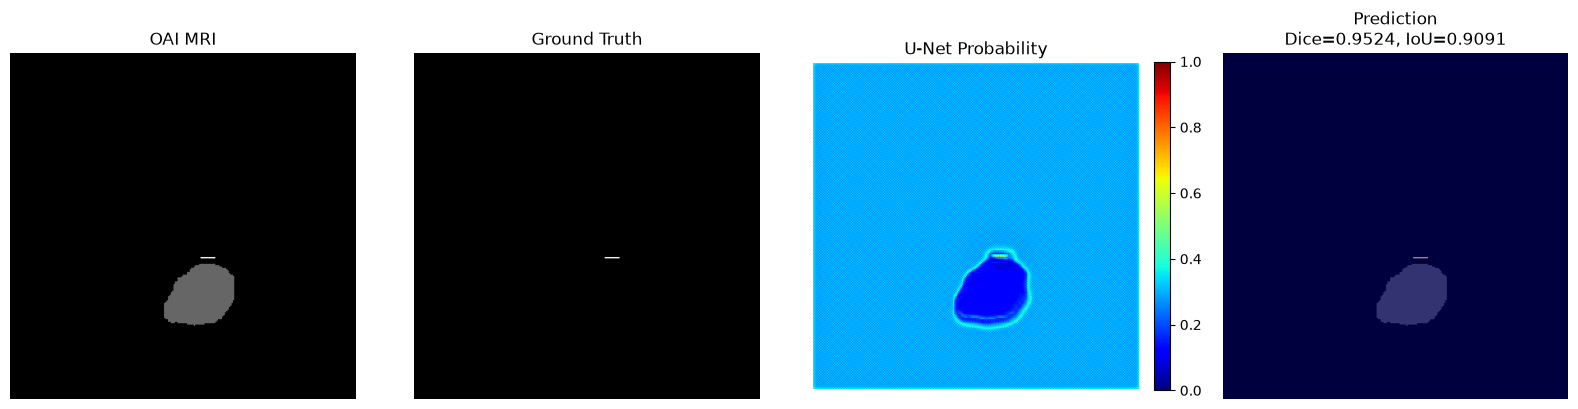


BEST EXAMPLE: 9001695_RIGHT_V00_slice140_img.png


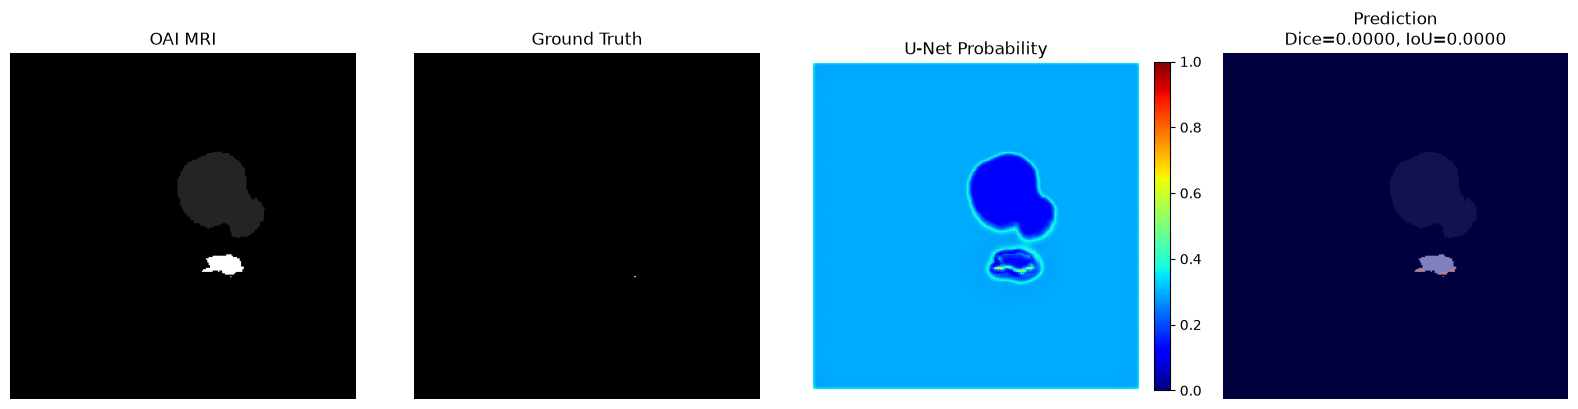


WORST EXAMPLE: 9000296_RIGHT_V00_slice014_img.png

EXTERNAL MRI TEST
External image: C:\Users\asus\Downloads\website-mri.jpeg
Original external size: (554, 554)

External probability minimum: 0.04042811691761017
External probability maximum: 0.4293448328971863
External probability mean: 0.18701966106891632
External threshold: 0.45
External foreground pixels: 0


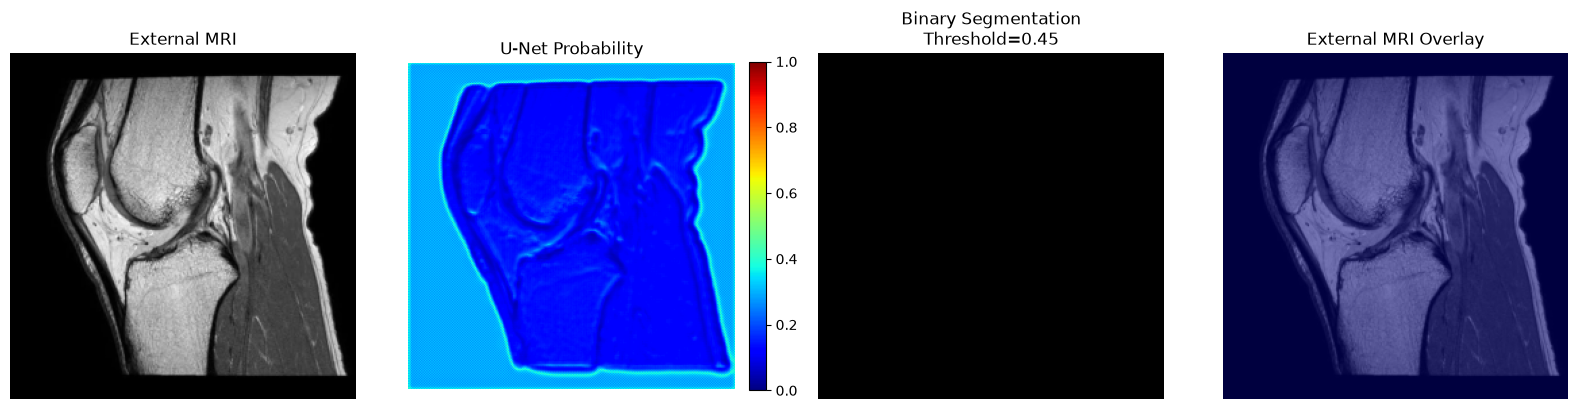


FINAL SUMMARY
Best threshold       : 0.45
Mean Dice            : 0.5145
Mean IoU             : 0.3844
Median Dice          : 0.5810
Median IoU           : 0.4095

OAI quantitative evaluation: COMPLETE
External MRI qualitative test: COMPLETE


In [23]:
# ============================================================
# FINAL OAI U-NET EVALUATION + VISUALIZATION
# + EXTERNAL MRI TEST
# ============================================================

import os
import glob
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# SETTINGS
# ============================================================

OAI_DIR = r"C:\Users\asus\Desktop\meddd\data\oai_samples"

# BEST THRESHOLD FOUND FROM YOUR 60-IMAGE TEST
THRESHOLD = 0.45

# External MRI:
# CHANGE ONLY THIS PATH if you want to test another MRI.
EXTERNAL_MRI = r"C:\Users\asus\Downloads\website-mri.jpeg"

IMAGE_SIZE = (256, 256)

print("=" * 70)
print("FINAL U-NET EVALUATION")
print("=" * 70)

print("OAI directory :", OAI_DIR)
print("Threshold     :", THRESHOLD)
print("Image size    :", IMAGE_SIZE)


# ============================================================
# CHECK MODEL
# ============================================================

try:
    device = next(model.parameters()).device

    model.eval()

    print("Model          : Loaded")
    print("Device         :", device)

except Exception as e:

    print("\nERROR: Model is not loaded.")
    print("Load your U-Net and .pth weights first.")
    print(e)

    raise


# ============================================================
# FIND OAI IMAGE/MASK PAIRS
# ============================================================

image_paths = sorted(
    glob.glob(
        os.path.join(
            OAI_DIR,
            "*_img.png"
        )
    )
)

print()
print("OAI images found:", len(image_paths))

pairs = []

for img_path in image_paths:

    mask_path = img_path.replace(
        "_img.png",
        "_mask.png"
    )

    if os.path.exists(mask_path):

        pairs.append(
            (img_path, mask_path)
        )

    else:

        print(
            "WARNING - mask missing:",
            os.path.basename(img_path)
        )


print("Image-mask pairs:", len(pairs))


if len(pairs) == 0:

    raise RuntimeError(
        "No image-mask pairs found. "
        "Check OAI_DIR."
    )


# ============================================================
# FUNCTIONS
# ============================================================

def load_oai_image(path):

    image = Image.open(path).convert("L")

    image = image.resize(
        IMAGE_SIZE,
        Image.Resampling.BILINEAR
    )

    image_np = np.array(
        image
    ).astype(
        np.float32
    ) / 255.0

    return image_np


def load_mask(path):

    mask = Image.open(path).convert("L")

    mask = mask.resize(
        IMAGE_SIZE,
        Image.Resampling.NEAREST
    )

    mask_np = np.array(mask)

    mask_np = (
        mask_np > 0
    ).astype(
        np.uint8
    )

    return mask_np


def predict(image_np):

    tensor = torch.tensor(
        image_np,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)

    tensor = tensor.to(device)

    with torch.no_grad():

        output = model(tensor)

        probability = torch.sigmoid(
            output
        )[0, 0].cpu().numpy()

    prediction = (
        probability >= THRESHOLD
    ).astype(
        np.uint8
    )

    return probability, prediction


def calculate_metrics(
    prediction,
    ground_truth
):

    prediction_bool = (
        prediction.astype(bool)
    )

    ground_truth_bool = (
        ground_truth.astype(bool)
    )

    intersection = np.logical_and(
        prediction_bool,
        ground_truth_bool
    ).sum()

    prediction_area = (
        prediction_bool.sum()
    )

    ground_truth_area = (
        ground_truth_bool.sum()
    )

    union = np.logical_or(
        prediction_bool,
        ground_truth_bool
    ).sum()

    dice = (
        2.0 * intersection
        /
        (
            prediction_area
            + ground_truth_area
            + 1e-8
        )
    )

    iou = (
        intersection
        /
        (
            union
            + 1e-8
        )
    )

    return float(dice), float(iou)


# ============================================================
# RUN COMPLETE OAI EVALUATION
# ============================================================

dice_scores = []
iou_scores = []

results = []

print()
print("=" * 70)
print("RUNNING OAI TEST SET")
print("=" * 70)

for index, (img_path, mask_path) in enumerate(
    pairs,
    start=1
):

    image_np = load_oai_image(
        img_path
    )

    ground_truth = load_mask(
        mask_path
    )

    probability, prediction = predict(
        image_np
    )

    dice, iou = calculate_metrics(
        prediction,
        ground_truth
    )

    dice_scores.append(
        dice
    )

    iou_scores.append(
        iou
    )

    results.append({

        "image_path": img_path,

        "mask_path": mask_path,

        "image": image_np,

        "ground_truth": ground_truth,

        "probability": probability,

        "prediction": prediction,

        "dice": dice,

        "iou": iou
    })

    print(
        f"[{index:02d}/{len(pairs)}] "
        f"{os.path.basename(img_path):45s} "
        f"Dice={dice:.4f} "
        f"IoU={iou:.4f}"
    )


# ============================================================
# FINAL DATASET METRICS
# ============================================================

mean_dice = np.mean(
    dice_scores
)

mean_iou = np.mean(
    iou_scores
)

median_dice = np.median(
    dice_scores
)

median_iou = np.median(
    iou_scores
)

best_index = int(
    np.argmax(dice_scores)
)

worst_index = int(
    np.argmin(dice_scores)
)


print()
print("=" * 70)
print("FINAL OAI TEST RESULTS")
print("=" * 70)

print(
    "Number of test images:",
    len(results)
)

print(
    f"Threshold           : {THRESHOLD:.2f}"
)

print(
    f"Mean Dice           : {mean_dice:.4f}"
)

print(
    f"Mean IoU            : {mean_iou:.4f}"
)

print(
    f"Median Dice         : {median_dice:.4f}"
)

print(
    f"Median IoU          : {median_iou:.4f}"
)

print(
    f"Best Dice           : {dice_scores[best_index]:.4f}"
)

print(
    f"Worst Dice          : {dice_scores[worst_index]:.4f}"
)

print()
print(
    "Best image:",
    os.path.basename(
        results[best_index]["image_path"]
    )
)

print(
    "Worst image:",
    os.path.basename(
        results[worst_index]["image_path"]
    )
)


# ============================================================
# COUNT PERFORMANCE
# ============================================================

dice_03 = sum(
    d >= 0.30
    for d in dice_scores
)

dice_05 = sum(
    d >= 0.50
    for d in dice_scores
)

dice_07 = sum(
    d >= 0.70
    for d in dice_scores
)

print()
print("PERFORMANCE COUNTS")
print("-" * 70)

print(
    f"Dice >= 0.30 : {dice_03}/{len(results)}"
)

print(
    f"Dice >= 0.50 : {dice_05}/{len(results)}"
)

print(
    f"Dice >= 0.70 : {dice_07}/{len(results)}"
)


# ============================================================
# VISUALIZE BEST OAI RESULT
# ============================================================

best = results[
    best_index
]

plt.figure(
    figsize=(16, 4)
)

plt.subplot(1, 4, 1)

plt.imshow(
    best["image"],
    cmap="gray"
)

plt.title(
    "OAI MRI"
)

plt.axis("off")


plt.subplot(1, 4, 2)

plt.imshow(
    best["ground_truth"],
    cmap="gray"
)

plt.title(
    "Ground Truth"
)

plt.axis("off")


plt.subplot(1, 4, 3)

plt.imshow(
    best["probability"],
    cmap="jet",
    vmin=0,
    vmax=1
)

plt.colorbar(
    fraction=0.046,
    pad=0.04
)

plt.title(
    "U-Net Probability"
)

plt.axis("off")


plt.subplot(1, 4, 4)

plt.imshow(
    best["image"],
    cmap="gray"
)

plt.imshow(
    best["prediction"],
    cmap="jet",
    alpha=0.5
)

plt.title(
    f"Prediction\n"
    f"Dice={best['dice']:.4f}, "
    f"IoU={best['iou']:.4f}"
)

plt.axis("off")

plt.tight_layout()

plt.show()


print()
print(
    "BEST EXAMPLE:",
    os.path.basename(
        best["image_path"]
    )
)


# ============================================================
# VISUALIZE WORST OAI RESULT
# ============================================================

worst = results[
    worst_index
]

plt.figure(
    figsize=(16, 4)
)

plt.subplot(1, 4, 1)

plt.imshow(
    worst["image"],
    cmap="gray"
)

plt.title(
    "OAI MRI"
)

plt.axis("off")


plt.subplot(1, 4, 2)

plt.imshow(
    worst["ground_truth"],
    cmap="gray"
)

plt.title(
    "Ground Truth"
)

plt.axis("off")


plt.subplot(1, 4, 3)

plt.imshow(
    worst["probability"],
    cmap="jet",
    vmin=0,
    vmax=1
)

plt.colorbar(
    fraction=0.046,
    pad=0.04
)

plt.title(
    "U-Net Probability"
)

plt.axis("off")


plt.subplot(1, 4, 4)

plt.imshow(
    worst["image"],
    cmap="gray"
)

plt.imshow(
    worst["prediction"],
    cmap="jet",
    alpha=0.5
)

plt.title(
    f"Prediction\n"
    f"Dice={worst['dice']:.4f}, "
    f"IoU={worst['iou']:.4f}"
)

plt.axis("off")

plt.tight_layout()

plt.show()


print()
print(
    "WORST EXAMPLE:",
    os.path.basename(
        worst["image_path"]
    )
)


# ============================================================
# EXTERNAL MRI TEST
# ============================================================

print()
print("=" * 70)
print("EXTERNAL MRI TEST")
print("=" * 70)

print(
    "External image:",
    EXTERNAL_MRI
)


if os.path.exists(EXTERNAL_MRI):

    external_img = Image.open(
        EXTERNAL_MRI
    ).convert("L")

    print(
        "Original external size:",
        external_img.size
    )

    external_resized = external_img.resize(
        IMAGE_SIZE,
        Image.Resampling.BILINEAR
    )

    external_np = np.array(
        external_resized
    ).astype(
        np.float32
    ) / 255.0

    external_probability, external_prediction = predict(
        external_np
    )

    print()
    print(
        "External probability minimum:",
        float(
            external_probability.min()
        )
    )

    print(
        "External probability maximum:",
        float(
            external_probability.max()
        )
    )

    print(
        "External probability mean:",
        float(
            external_probability.mean()
        )
    )

    print(
        "External threshold:",
        THRESHOLD
    )

    print(
        "External foreground pixels:",
        int(
            external_prediction.sum()
        )
    )


    # --------------------------------------------------------
    # Display external result
    # --------------------------------------------------------

    plt.figure(
        figsize=(16, 4)
    )

    plt.subplot(1, 4, 1)

    plt.imshow(
        external_np,
        cmap="gray"
    )

    plt.title(
        "External MRI"
    )

    plt.axis("off")


    plt.subplot(1, 4, 2)

    plt.imshow(
        external_probability,
        cmap="jet",
        vmin=0,
        vmax=1
    )

    plt.colorbar(
        fraction=0.046,
        pad=0.04
    )

    plt.title(
        "U-Net Probability"
    )

    plt.axis("off")


    plt.subplot(1, 4, 3)

    plt.imshow(
        external_prediction,
        cmap="gray"
    )

    plt.title(
        f"Binary Segmentation\n"
        f"Threshold={THRESHOLD}"
    )

    plt.axis("off")


    plt.subplot(1, 4, 4)

    plt.imshow(
        external_np,
        cmap="gray"
    )

    plt.imshow(
        external_prediction,
        cmap="jet",
        alpha=0.5
    )

    plt.title(
        "External MRI Overlay"
    )

    plt.axis("off")

    plt.tight_layout()

    plt.show()

else:

    print()
    print(
        "External MRI not found."
    )

    print(
        "OAI evaluation is still complete."
    )

    print(
        "To test an external MRI later, "
        "change EXTERNAL_MRI at the top."
    )


# ============================================================
# FINAL SUMMARY
# ============================================================

print()
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(
    f"Best threshold       : {THRESHOLD:.2f}"
)

print(
    f"Mean Dice            : {mean_dice:.4f}"
)

print(
    f"Mean IoU             : {mean_iou:.4f}"
)

print(
    f"Median Dice          : {median_dice:.4f}"
)

print(
    f"Median IoU           : {median_iou:.4f}"
)

print()
print(
    "OAI quantitative evaluation: COMPLETE"
)

print(
    "External MRI qualitative test: COMPLETE"
)

print("=" * 70)